# Preliminary calibrated $\pi^0$ cross sections: x36_4, x36_5_407, and joint fit

**Preliminary — Hall C NPS analysis — provenance snapshot: 2026-10-06**

This notebook presents the frozen calibrated individual extractions for x36_4 and
x36_5_407, their simultaneous LH2 joint M0 fit, and the stored two-setting T/L
separation. It reads existing extraction products only; it does **not** rerun event
production, cross-section extraction, fits, or toy campaigns.

The producer convention is

$$2\pi\,\frac{d^2\sigma}{dt\,d\phi}=
\sigma_U+\sqrt{2\epsilon(1+\epsilon)}\,\sigma_{LT}\cos\phi
+\epsilon\,\sigma_{TT}\cos 2\phi,$$

with $\sigma_U=\sigma_T+\epsilon\sigma_L$. Cross sections are in nb/GeV$^2$.
Individual releases are frozen constrained additive-weight M0 fits. The joint fit has
per-setting U normalization/slope, shared LT/TT parameters, and fitted low-$-t'$ feed-in
terms. The statistical radius is
$\delta_{68}=Q_{0.68}(|z_{\rm toy}-z_{\rm truth}|)$, not an assumed Gaussian standard
deviation.

Selection conventions differ and are kept distinct: individual fits use the stored
$0.8\leq M_X\leq1.1$ GeV window, while the joint fit uses the combined-data
two-dimensional ellipse flag. Both use the same rectangular limits intersected with
the exact four-vertex $(x_B,Q^2)$ diamond. “Before selection” below means all records
in the combined physics tree; upstream reconstruction/PID cuts have already occurred.


In [1]:
from pathlib import Path
import hashlib, json, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon, Rectangle
from IPython.display import display
import uproot

warnings.filterwarnings("ignore", message="A NumPy version.*is required for this version of SciPy")
from scipy.stats import chi2 as chi2_distribution

REPO=Path("/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main")
OUTPUT_DIR=REPO/"output/publication_figures/x36_4_x36_5_407_calibrated"
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
KIN_ORDER=["KinC_x36_5_407","KinC_x36_4"]
KIN_SHORT={"KinC_x36_5_407":"x36_5_407","KinC_x36_4":"x36_4"}
COLORS={"KinC_x36_5_407":"#D55E00","KinC_x36_4":"#0072B2"}
MARKERS={"KinC_x36_5_407":"^","KinC_x36_4":"o"}
COMPONENT_LABEL={"U":r"$\sigma_U$","LT":r"$\sigma_{LT}$","TT":r"$\sigma_{TT}$"}
FIGURE_RECORDS=[]

mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":320,"font.size":9,
 "axes.labelsize":10,"axes.titlesize":10,"legend.fontsize":8,"xtick.labelsize":8,
 "ytick.labelsize":8,"axes.linewidth":0.8,"lines.linewidth":1.4,"lines.markersize":5.5,
 "xtick.direction":"in","ytick.direction":"in","xtick.top":True,"ytick.right":True,
 "axes.grid":False,"pdf.fonttype":42,"ps.fonttype":42})

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()

def load_json(path):
    path=Path(path)
    if not path.is_file(): raise FileNotFoundError(f"Missing JSON: {path}")
    return json.loads(path.read_text())

def load_csv(path,required,unique=None):
    path=Path(path)
    if not path.is_file(): raise FileNotFoundError(f"Missing CSV: {path}")
    df=pd.read_csv(path); missing=sorted(set(required)-set(df.columns))
    if missing: raise ValueError(f"{path}: missing columns {missing}")
    if df.empty: raise ValueError(f"{path}: empty table")
    if unique and df.duplicated(list(unique)).any(): raise ValueError(f"{path}: duplicate key {unique}")
    return df

def require_finite(df,columns,label):
    a=df[list(columns)].apply(pd.to_numeric,errors="coerce").to_numpy(float)
    if not np.isfinite(a).all(): raise ValueError(f"{label}: non-finite values in {columns}")

def preliminary(ax):
    fig=ax.figure
    fig.text(.02,.955,r"$\mathbf{NPS\ RG1a}\ \mathit{Preliminary}$",
             transform=fig.transFigure,ha="left",va="center",
             color="black",fontsize=12.5,clip_on=False,zorder=30)
    fig._has_preliminary_label=True

def export_figure(fig,stem,description):
    if getattr(fig,"_has_preliminary_label",False):
        fig.subplots_adjust(top=min(fig.subplotpars.top,.89))
    pdf=OUTPUT_DIR/f"{stem}.pdf"; png=OUTPUT_DIR/f"{stem}.png"
    fig.savefig(pdf,bbox_inches="tight",metadata={"Title":description,"Creator":"plot_xsec_x36_4_x36_5_407.ipynb"})
    fig.savefig(png,dpi=320,bbox_inches="tight")
    FIGURE_RECORDS.append({"figure":stem,"PDF":str(pdf.relative_to(REPO)),
                           "PNG":str(png.relative_to(REPO)),"shows":description})
    display(fig); plt.close(fig)

def ordered_matrix(df):
    labels=df.iloc[:,0].astype(str).tolist()
    if labels!=list(df.columns[1:]): raise ValueError("Matrix labels differ")
    a=df.iloc[:,1:].to_numpy(float)
    if a.shape!=(len(labels),len(labels)) or not np.isfinite(a).all(): raise ValueError("Invalid matrix")
    return labels,a

print("Repository:",REPO)
print("Figure output:",OUTPUT_DIR)

Repository: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main
Figure output: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/publication_figures/x36_4_x36_5_407_calibrated


## Immutable input manifest

Every consumed file is verified against this pre-implementation SHA-256 manifest before
loading and again after all exports. Paths are repository-relative. ROOT files are read
with uproot; no ROOT macro is executed.


In [2]:
INPUTS={
"src/xsec_extract/xsec_config/xsec_config_x36_4.json":("055a75e2d4d494cb618b1fa38a3ea0c86cce4f85117bdb61e029980d2988baa2","x36_4 cuts/binning"),
"src/xsec_extract/xsec_config/xsec_config_x36_5_407.json":("22ecb70d5130a6b6e2eca64d8d4aa136648600e00be3eb54fdf36ff54777a1dd","x36_5_407 cuts/binning"),
"output/KinC_x36_4/xsec_calibrated/preliminary_cross_sections_calibrated.csv":("e02ce021695f378ab17ee9c055b5a3d6c5b6a8e1b9d5496655b22cc47454c7c0","x36_4 responses"),
"output/KinC_x36_4/xsec_calibrated/published_covariance_calibrated68.csv":("b4c8e372d1af87943a7cac7c5d1354dcf1c8c0f323c51afb6232ae8d15c4b10e","x36_4 calibrated response covariance representation"),
"output/KinC_x36_4/xsec_calibrated/toy_residual_statistics.csv":("c3940b17731fb6852241d34aa2eeff52c08050a0496e736bc1c2f80ad174d192","x36_4 interval/calibration diagnostics"),
"output/KinC_x36_4/xsec_calibrated/bin_statistics.csv":("a86599c2849ceabf27d7850c8c062ae7ad7c9a41540bb47a247e435d69b22f01","x36_4 weighted occupancy"),
"output/KinC_x36_4/xsec_calibrated/calibration_summary.json":("898694aaf2069c3415f699773eec35f02fd48ebcdbc35e5d1bf0e9259ac912d1","x36_4 fit status"),
"output/KinC_x36_5_407/xsec_calibrated/preliminary_cross_sections_calibrated.csv":("445bebdca384563ff56833ad486a59567204fedf676deb3d207a9ac55b861885","x36_5_407 responses"),
"output/KinC_x36_5_407/xsec_calibrated/published_covariance_calibrated68.csv":("34fdac4b6287af1ec0d1df3f348d67a940c30dbde04b137501fb36ef8cb9ff9b","x36_5_407 calibrated response covariance representation"),
"output/KinC_x36_5_407/xsec_calibrated/toy_residual_statistics.csv":("5b2c682f87bd962b35dc5bcf491ebb0fcfb30a827405a5a83cbc2c8243575539","x36_5_407 interval/calibration diagnostics"),
"output/KinC_x36_5_407/xsec_calibrated/bin_statistics.csv":("2a18fd763c3b4ae9ed9070e4c46d97e90983f1d37eda212f37543ffe159612a1","x36_5_407 weighted occupancy"),
"output/KinC_x36_5_407/xsec_calibrated/calibration_summary.json":("39d18c45fb54514d5a2a2975759b3781771394964b3908f47fa4c0a042854c8c","x36_5_407 fit status"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_preliminary_cross_sections_calibrated.csv":("18fd59369d467fd0e5a315a016bec4dee0f05988fb887943b85f33fd0bab7bd2","joint responses/systematic"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/published_covariance_calibrated68.csv":("b1bedb41dc379e3cf155d809045fb3c5e91c0ad305516b5df8b92eee0703d109","joint calibrated response covariance representation"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/toy_residual_statistics.csv":("08a686c5fa3598f2194cc068d6268c939e2f8bcc3225f35327b192dbb4802399","joint interval/calibration diagnostics"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/published_correlation_toy.csv":("88c200dc082bc17afe203c420e8878a0de46cdab59f30d85f124e028119d3831","joint response correlations"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_parameter_correlation_toy.csv":("d180da559d92e4e16a260eddc7bdb8c5eb3460dcad8552ee0e7d2adbb3820321","joint parameter correlations"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/calibration_summary.json":("5985b39a08319541087959e6e505adac9d29b13b7a724bf19a5a8d8cc2f19209","joint fit/toy status"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/joint_lt_separated_cross_sections.csv":("9f049672120ef4cb1aa47c38a2dc2487f5da7b066e4dc293db2eeacc7db9fa22","stored T/L responses"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/joint_lt_covariance_calibrated68.csv":("c4c2f2f194c432409c3b45364c27dde1409c51835c8a7b9e01198cfdcbf56725","T/L calibrated covariance representation"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/joint_lt_correlation_toy.csv":("820de32f25d99f1e13c88a0ec8663ed373f4dbc5db5abc678abedb8cb9f356ed","T/L correlations"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/calibration_summary.json":("4d0d64c7b438bd7f72d82e7157b72fe77fba1d68d4079d5c23d450b901c97ae9","T/L convention/epsilon"),
"output/joint_x36_5_407_x36_4_LH2/joint_manifest.json":("cfd4c67102c58dfc0859e945272963b9ca0085f4c5f2266cdaba0de0ebe01a3c","joint selection/bin contract"),
"output/joint_x36_5_407_x36_4_LH2/toy_campaigns/20261006T052846_1954381/central.json":("f6a21018637ff602a52b59d1fd2d3f19f7331d2afa720677f42de5e6e22fa4c6","frozen central metadata"),
"output/joint_x36_5_407_x36_4_LH2/toy_campaigns/20261006T052846_1954381/central.npz":("7c390dc6ec3f8bf871f75e9518af766f1236a584bb7f4226055843ef16517d69","frozen yields/prediction/covariance"),
"output/joint_x36_5_407_x36_4_LH2/toy_campaigns/20261006T052846_1954381/toys/replicas.npz":("ad62910f0d7fb888989c2bd734140087c585a2d6330e96366c81995a4ec3475d","500 accepted joint toys"),
"output/joint_x36_5_407_x36_4_LH2_inputs/KinC_x36_5_407/migration_reco_rows.csv":("37082c321b60526fb480ba23a1a5e1ec21b9ee3f49ca0c8fea8bc5b6a0660712","x36_5_407 phi-row coordinates"),
"output/joint_x36_5_407_x36_4_LH2_inputs/KinC_x36_4/migration_reco_rows.csv":("5f8e5c949c16fc7ae43315b02de6c1ef59d2daea13a00674db56aa271f6fd678","x36_4 phi-row coordinates"),
"output/KinC_x36_5_407/xsec/migration_singular_values.csv":("2e5119aab313a8e7daf1e0d1a14a00c3755ca37348b74d0e70f9cf9c5f0cd355","x36_5_407 original-xsec normalized design singular values"),
"output/KinC_x36_5_407/xsec/migration_parameters.csv":("730549445f80e52b4bd5d3b3f3a93c30a1d771f497c8a906a6050c9fd9e2ac21","x36_5_407 original-xsec parameter inventory"),
"output/KinC_x36_5_407/xsec/migration_reco_rows.csv":("8f3f7d32bebc5db5643496748f74af82188bbfb1eb652c782c44d0a8ff58de18","x36_5_407 original-xsec fitted rows and pulls"),
"output/KinC_x36_5_407/xsec/positivity_diagnostics.csv":("533f140a27f4a81d8f512b041fbe9d2ed2ed5e9847524ffec1cbe15ccc83ddee","x36_5_407 original-xsec positivity boundaries"),
"output/KinC_x36_5_407/xsec/fit_status.csv":("08e004180647302bb66458effa30b115e9ae0a0946398cac7eee4adf8887247d","x36_5_407 original-xsec fit status"),
"output/KinC_x36_4/xsec/migration_singular_values.csv":("932d464d9cb1366c7bb5652fc62b71e38b120bc5b2d3fb2d343ed9c086f9e96c","x36_4 original-xsec normalized design singular values"),
"output/KinC_x36_4/xsec/migration_parameters.csv":("4208232258a3899d712013dd3984fad78cf2849a00bd8ab0535b1394fea86386","x36_4 original-xsec parameter inventory"),
"output/KinC_x36_4/xsec/migration_reco_rows.csv":("3371e9cc86de5cf845043bedb864fafdf4c076e17286d500b02f0df59742ca77","x36_4 original-xsec fitted rows and pulls"),
"output/KinC_x36_4/xsec/positivity_diagnostics.csv":("cb68d8d0620a28759534eb3bce9503beb60a0d3b4f822a3cbfc01e9972651b7f","x36_4 original-xsec positivity boundaries"),
"output/KinC_x36_4/xsec/fit_status.csv":("08e004180647302bb66458effa30b115e9ae0a0946398cac7eee4adf8887247d","x36_4 original-xsec fit status"),
"output/KinC_x36_5_407/xsec/excl_xsec_pi0_analysis_no_simc_model_slice_summary.csv":("47e6a14fdf28acd108a0d251c885f0257b4ff0133a7135995ebfc185c26ba349","x36_5_407 legacy published tprime bin edges"),
"output/KinC_x36_4/xsec/excl_xsec_pi0_analysis_no_simc_model_slice_summary.csv":("6ba0807600b35e379a46fe8b210c857e05d36f6c14ae2cf6ee50606e730d16e8","x36_4 legacy published tprime bin edges"),
"output/KinC_x36_5_407/xsec_no_simc_model_calibrated/calibration_summary.json":("16f832f1a9ddf87e82e31661790579f39fd5bc1cedcb0d62b1393227b67cd426","x36_5_407 alternate-bin no-SIMC calibration summary"),
"output/KinC_x36_5_407/xsec_no_simc_model_calibrated/pipeline_linkage.json":("67fabf7ebffee156861b67bd1f12b77240522ce124d663f61914f1facc4cb681","x36_5_407 alternate-bin no-SIMC central-fit linkage"),
"output/KinC_x36_5_407/xsec_no_simc_model_calibrated/bin_statistics.csv":("a532b3607a3e8dfd0cbcad5b9a071891086f02f0b1d084a07d7b7152a0ffc966","x36_5_407 alternate-bin no-SIMC bin statistics"),
"output/KinC_x36_5_407/xsec_no_simc_model_calibrated/toy_residual_statistics.csv":("21e363150ed359953ef06646326463510cc9f89e29a387c051e6530f79ae2b6a","x36_5_407 alternate-bin no-SIMC toy diagnostics"),
"output/KinC_x36_5_407/xsec_no_simc_model_calibrated/published_covariance_calibrated68.csv":("1c5fb233cba289d42288b3c289967c778b31a37a437eba7d6bccd7ddc9eaafc6","x36_5_407 alternate-bin no-SIMC calibrated covariance representation"),
"output/KinC_x36_4/xsec_no_simc_model_calibrated/calibration_summary.json":("210e05f8c2abadfb82e19dc27c5750baa24e5cd6eea9ee004be01b4113b5ea08","x36_4 alternate-bin no-SIMC calibration summary"),
"output/KinC_x36_4/xsec_no_simc_model_calibrated/pipeline_linkage.json":("06df710ea3ff13f12d92ebf8e4f8ec09e29fa334e76b6f3b72c2ce9538894136","x36_4 alternate-bin no-SIMC central-fit linkage"),
"output/KinC_x36_4/xsec_no_simc_model_calibrated/bin_statistics.csv":("1014dfdcc1ae34ccbf3acc761b8e90ce3f7765943a23a2b4c959de7e737be409","x36_4 alternate-bin no-SIMC bin statistics"),
"output/KinC_x36_4/xsec_no_simc_model_calibrated/toy_residual_statistics.csv":("8e324853f2990c791e67e804ba9dac8c23074e6eee5a8bf835834af13eed9500","x36_4 alternate-bin no-SIMC toy diagnostics"),
"output/KinC_x36_4/xsec_no_simc_model_calibrated/published_covariance_calibrated68.csv":("ac4e149928022a0e1d480d93f15b808c85e9d9155429e828f79365c3fc028d5a","x36_4 alternate-bin no-SIMC calibrated covariance representation"),
"output/KinC_x36_5_407/xsec_no_simc_model/migration_singular_values.csv":("ddf3db83bc95936ab438be5b4313a3ee679d432fc50f65c7bb011413d739dbec","x36_5_407 alternate-bin no-SIMC normalized design singular values"),
"output/KinC_x36_5_407/xsec_no_simc_model/migration_parameters.csv":("15f489e7c61258fe553272596f149c555b9fbbfd1335c6add3f570048ffecfaf","x36_5_407 alternate-bin no-SIMC parameter inventory"),
"output/KinC_x36_5_407/xsec_no_simc_model/migration_reco_rows.csv":("2f1d3a33eb0b278a8a9b13f37b9b66966197e658ded4e77e4b35830b3d1497b8","x36_5_407 alternate-bin no-SIMC fitted rows and pulls"),
"output/KinC_x36_5_407/xsec_no_simc_model/positivity_diagnostics.csv":("963346a1e6e508ff026d6863bc50c13abd6178a2ff3c5a311427e8194108af97","x36_5_407 alternate-bin no-SIMC positivity boundaries"),
"output/KinC_x36_5_407/xsec_no_simc_model/fit_status.csv":("08e004180647302bb66458effa30b115e9ae0a0946398cac7eee4adf8887247d","x36_5_407 alternate-bin no-SIMC fit status"),
"output/KinC_x36_4/xsec_no_simc_model/migration_singular_values.csv":("9d6ee18c4f09a522d82ad8d79c7753b5610449c8eb122025093e2a06707b02f8","x36_4 alternate-bin no-SIMC normalized design singular values"),
"output/KinC_x36_4/xsec_no_simc_model/migration_parameters.csv":("bdaa3e245da95c0032d4b515d1b11bc1a10cf460549422fb3bb4bec72afcfa1f","x36_4 alternate-bin no-SIMC parameter inventory"),
"output/KinC_x36_4/xsec_no_simc_model/migration_reco_rows.csv":("7484674c771b9e78628b36e771850778c5e46895540949c1fcab5a3fc82dce76","x36_4 alternate-bin no-SIMC fitted rows and pulls"),
"output/KinC_x36_4/xsec_no_simc_model/positivity_diagnostics.csv":("fdbac22f342ebac22be751bc46734936aee93b9a70e1d3c52d48d3af4b6d7a75","x36_4 alternate-bin no-SIMC positivity boundaries"),
"output/KinC_x36_4/xsec_no_simc_model/fit_status.csv":("08e004180647302bb66458effa30b115e9ae0a0946398cac7eee4adf8887247d","x36_4 alternate-bin no-SIMC fit status"),
"output/KinC_x36_5_407/xsec_simc_model/toy_campaigns/20261006T035631_3735066/feedin_refactor_validation.json":("cf73f0d29beeca87cdb79d0c25b14cae5138b1b69322a49947569880b008da73","x36_5_407 frozen M0 scaled-Jacobian validation"),
"output/KinC_x36_4/xsec_simc_model/toy_campaigns/20261006T040119_3879649/feedin_refactor_validation.json":("49aedd7291c9e517e4c9712c3979fd033692c6bf39df58c0c217cd79e4f28952","x36_4 frozen M0 scaled-Jacobian validation"),
"output/KinC_x36_5_407/KinC_x36_5/root/combined_branches_LH2.root":("b6616c972878882afe2c513b80ce6fb31c42ed44ba67ebc62b863ee0cd8e3d10","x36_5_407 data phase space"),
"output/KinC_x36_4/root/combined_branches_LH2.root":("a406e48af8ea690f9de303e41787d7ae8b214fceae6b2a459a8be3999bbd6338","x36_4 data phase space")}
rows=[]
for rel,(expected,role) in INPUTS.items():
    got=sha256(REPO/rel)
    if got!=expected: raise RuntimeError(f"Checksum mismatch: {rel}")
    rows.append({"path":rel,"role":role,"sha256":got})
input_manifest=pd.DataFrame(rows)
display(input_manifest)
print(f"Verified {len(input_manifest)} immutable inputs before loading.")

,path,role,sha256
0,src/xsec_extract/xsec_config/xsec_config_x36_4...,x36_4 cuts/binning,055a75e2d4d494cb618b1fa38a3ea0c86cce4f85117bdb...
1,src/xsec_extract/xsec_config/xsec_config_x36_5...,x36_5_407 cuts/binning,22ecb70d5130a6b6e2eca64d8d4aa136648600e00be3eb...
2,output/KinC_x36_4/xsec_calibrated/preliminary_...,x36_4 responses,e02ce021695f378ab17ee9c055b5a3d6c5b6a8e1b9d549...
3,output/KinC_x36_4/xsec_calibrated/published_co...,x36_4 calibrated response covariance represent...,b4c8e372d1af87943a7cac7c5d1354dcf1c8c0f323c51a...
4,output/KinC_x36_4/xsec_calibrated/toy_residual...,x36_4 interval/calibration diagnostics,c3940b17731fb6852241d34aa2eeff52c08050a0496e73...
...,...,...,...
59,output/KinC_x36_4/xsec_no_simc_model/fit_statu...,x36_4 alternate-bin no-SIMC fit status,08e004180647302bb66458effa30b115e9ae0a0946398c...
60,output/KinC_x36_5_407/xsec_simc_model/toy_camp...,x36_5_407 frozen M0 scaled-Jacobian validation,cf73f0d29beeca87cdb79d0c25b14cae5138b1b69322a4...
61,output/KinC_x36_4/xsec_simc_model/toy_campaign...,x36_4 frozen M0 scaled-Jacobian validation,49aedd7291c9e517e4c9712c3979fd033692c6bf39df58...
62,output/KinC_x36_5_407/KinC_x36_5/root/combined...,x36_5_407 data phase space,b6616c972878882afe2c513b80ce6fb31c42ed44ba67eb...


Verified 64 immutable inputs before loading.


## Loaders, schemas, and analysis contracts

The exact diamond vertices are listed below in producer order. The accepted region is
the intersection of this polygon with $3.3\le Q^2\le4.7$ GeV$^2$,
$0.29\le x_B\le0.44$, $-0.7\le t'<0$ GeV$^2$, and finite wrapped $\phi$.
Bin 0 is the largest-$-t'$ bin; bin 4 is closest to the forward limit.


In [3]:
CFG_PATH={k:REPO/f"src/xsec_extract/xsec_config/xsec_config_{k.replace('KinC_','')}.json" for k in KIN_ORDER}
IND_DIR={k:REPO/f"output/{k}/xsec_calibrated" for k in KIN_ORDER}
JOINT_DIR=REPO/"output/joint_x36_5_407_x36_4_LH2_calibrated"
JOINT_RAW=REPO/"output/joint_x36_5_407_x36_4_LH2"
JOINT_INPUT=REPO/"output/joint_x36_5_407_x36_4_LH2_inputs"
ROOT_PATH={"KinC_x36_5_407":REPO/"output/KinC_x36_5_407/KinC_x36_5/root/combined_branches_LH2.root",
           "KinC_x36_4":REPO/"output/KinC_x36_4/root/combined_branches_LH2.root"}

configs={k:load_json(p) for k,p in CFG_PATH.items()}
joint_manifest=load_json(JOINT_RAW/"joint_manifest.json")
joint_summary=load_json(JOINT_DIR/"calibration_summary.json")
lt_summary=load_json(JOINT_DIR/"joint_lt_separation/calibration_summary.json")
individual_summary={k:load_json(IND_DIR[k]/"calibration_summary.json") for k in KIN_ORDER}
individual={}; individual_residual={}; bin_stats={}
for k in KIN_ORDER:
    individual[k]=load_csv(IND_DIR[k]/"preliminary_cross_sections_calibrated.csv",
      ["tprime_bin","tprime_low","tprime_high","response_weighted_tprime","sigma_U","U_delta68_stat",
       "sigma_LT","LT_delta68_stat","sigma_TT","TT_delta68_stat","units","status"],["tprime_bin"])
    individual_residual[k]=load_csv(IND_DIR[k]/"toy_residual_statistics.csv",
      ["quantity","component","tprime_bin","central","delta68","basic_interval_lower","basic_interval_upper",
       "use_basic_interval","toy_mean_bias","abs_bias_over_delta68","cross_validated_coverage68","units"],
      ["component","tprime_bin"])
    bin_stats[k]=load_csv(IND_DIR[k]/"bin_statistics.csv",
      ["tprime_bin","tprime_low","tprime_high","response_weighted_tprime","included_phi_rows",
       "effective_entries","relative_weighted_yield_error"],["tprime_bin"])

individual_cov={}
expected_individual_labels=[f"{c}(bin{b})" for c in ["U","LT","TT"] for b in range(5)]
for k in KIN_ORDER:
    labels,cov=ordered_matrix(pd.read_csv(IND_DIR[k]/"published_covariance_calibrated68.csv"))
    if labels!=expected_individual_labels: raise ValueError(f"{k}: unexpected covariance labels")
    individual_cov[k]=cov

joint=load_csv(JOINT_DIR/"joint_preliminary_cross_sections_calibrated.csv",
 ["setting_index","kinematic","component","truth_block","response_weighted_tprime","value","delta68_stat",
  "basic_interval_lower","basic_interval_upper","target_systematic","units","status"],
 ["kinematic","component","truth_block"])
joint_residual=load_csv(JOINT_DIR/"toy_residual_statistics.csv",
 ["quantity","central","toy_mean_bias","delta68","use_basic_interval","cross_validated_coverage68",
  "target_systematic_absolute","units"],["quantity"])
lt=load_csv(JOINT_DIR/"joint_lt_separation/joint_lt_separated_cross_sections.csv",
 ["quantity","component","tprime_bin","tprime_center","central","delta68_stat","basic_interval_lower",
  "basic_interval_upper","use_basic_interval","cross_validated_coverage68","toy_mean_bias",
  "target_scale_systematic","units"],["component","tprime_bin"])
published_labels,published_corr=ordered_matrix(pd.read_csv(JOINT_DIR/"published_correlation_toy.csv"))
joint_cov_labels,joint_cov68=ordered_matrix(pd.read_csv(JOINT_DIR/"published_covariance_calibrated68.csv"))
if joint_cov_labels!=published_labels: raise ValueError("Joint covariance/correlation labels differ")
parameter_labels,parameter_corr=ordered_matrix(pd.read_csv(JOINT_DIR/"joint_parameter_correlation_toy.csv"))
lt_labels,lt_corr=ordered_matrix(pd.read_csv(JOINT_DIR/"joint_lt_separation/joint_lt_correlation_toy.csv"))
lt_cov_labels,lt_cov68=ordered_matrix(pd.read_csv(JOINT_DIR/"joint_lt_separation/joint_lt_covariance_calibrated68.csv"))
assert lt_labels==lt_cov_labels

central_json=load_json(JOINT_RAW/"toy_campaigns/20261006T052846_1954381/central.json")
with np.load(JOINT_RAW/"toy_campaigns/20261006T052846_1954381/central.npz") as z:
    central={n:z[n].copy() for n in z.files}
with np.load(JOINT_RAW/"toy_campaigns/20261006T052846_1954381/toys/replicas.npz") as z:
    toys={n:z[n].copy() for n in z.files}

maps=[]
for setting,k in enumerate(KIN_ORDER):
    f=load_csv(JOINT_INPUT/k/"migration_reco_rows.csv",["reco_row","it","ip","phi_lo","phi_hi"],["reco_row"])
    f=f.sort_values("reco_row").reset_index(drop=True); f["setting_index"]=setting; f["kinematic"]=k; maps.append(f)
row_map=pd.concat(maps,ignore_index=True)
for n in ["y","prediction","variance","data_variance"]: row_map[n]=central[n]
row_map["phi_center"]=(row_map.phi_lo+row_map.phi_hi)/2
row_map["pull"]=(row_map.y-row_map.prediction)/np.sqrt(row_map.variance)
row_map["ratio"]=row_map.y/row_map.prediction
row_map["ratio_error"]=np.sqrt(row_map.variance)/row_map.prediction

branches=["event_id","run_number","Q2","xB","t","tmin","phi","mmiss_all","mpi0_all","is_exclusive_ellipse_combined"]
phase={}
for k,p in ROOT_PATH.items():
    with uproot.open(p) as f:
        missing=sorted(set(branches)-set(f["physics"].keys()))
        if missing: raise ValueError(f"{p}: missing branches {missing}")
        phase[k]=pd.DataFrame(f["physics"].arrays(branches,library="np"))
    phase[k]["tprime"]=phase[k].t.astype(float)-phase[k].tmin.astype(float)

diamond=np.asarray(joint_manifest["bins"]["diamond_xb_q2_vertices"],float)
tprime_edges=np.asarray(joint_manifest["bins"]["tprime_bin_edges"],float)
q2_edges=np.asarray(joint_manifest["bins"]["q2_bin_edges"],float)
xb_edges=np.asarray(joint_manifest["bins"]["xb_bin_edges_by_q2"][0],float)
phi_edges=np.asarray(joint_manifest["bins"]["phi_bin_edges"],float)

def inside_diamond(xb,q2):
    xb=np.asarray(xb,float); q2=np.asarray(q2,float)
    cross=np.array([(b[0]-a[0])*(q2-a[1])-(b[1]-a[1])*(xb-a[0])
                    for a,b in zip(diamond,np.roll(diamond,-1,axis=0))])
    return np.all(cross>=-1e-12,axis=0)|np.all(cross<=1e-12,axis=0)

def kinematic_mask(f):
    finite=np.isfinite(f[["Q2","xB","tprime","phi"]]).all(axis=1).to_numpy()
    return (finite & f.Q2.between(*q2_edges,inclusive="both").to_numpy()
      & f.xB.between(*xb_edges,inclusive="both").to_numpy()
      & f.tprime.between(tprime_edges[0],tprime_edges[-1],inclusive="left").to_numpy()
      & inside_diamond(f.xB,f.Q2))

selection_masks={}
for k,f in phase.items():
    c=configs[k]
    iw=f.mmiss_all.between(c["mmiss_lower_gev"],c["mmiss_upper_gev"],inclusive="both").to_numpy()
    je=f.is_exclusive_ellipse_combined.to_numpy()!=0
    selection_masks[k]={"individual_exclusive":iw,"joint_exclusive":je,
                        "individual_final":iw&kinematic_mask(f),"joint_final":je&kinematic_mask(f)}

vertices=pd.DataFrame(diamond,columns=["x_B","Q2_GeV2"],index=[f"V{i+1}" for i in range(4)])
display(vertices)
print("Individual selection:",{k:(configs[k]["mmiss_select"],configs[k]["mmiss_lower_gev"],configs[k]["mmiss_upper_gev"]) for k in KIN_ORDER})
print("Joint selection:",joint_manifest["selection"])

,x_B,Q2_GeV2
V1,0.285366,3.243862
V2,0.338223,3.619312
V3,0.439530,4.698466
V4,0.372148,4.244414


Individual selection: {'KinC_x36_5_407': ('window', 0.8, 1.1), 'KinC_x36_4': ('window', 0.8, 1.1)}
Joint selection: {'exclusive_selection': 'ellipse', 'sim_reconstructed_mass_selection': 'combined_data_geometry', 'mmiss_lower_gev': '0.59999999999999998', 'mmiss_upper_gev': '1.1000000000000001', 'target_contam_factor': '0.58399999999999996', 'target_contam_factor_err': '0.014'}


### Numerical validation before plotting

These assertions guard schemas, finiteness, nonnegative uncertainties, common binning,
point counts, fit status, campaign uniqueness, and dataset labels. Stored T/L values must
reproduce both joint sigma_U points to floating-point precision.


In [4]:
for k in KIN_ORDER:
    a=individual[k]; r=individual_residual[k]
    assert len(a)==5 and len(r)==15 and len(bin_stats[k])==5
    assert a.tprime_bin.tolist()==list(range(5))
    assert np.all(np.diff(a.tprime_low)>0) and np.all(a.tprime_low<a.tprime_high)
    require_finite(a,["response_weighted_tprime","sigma_U","U_delta68_stat","sigma_LT",
                      "LT_delta68_stat","sigma_TT","TT_delta68_stat"],k)
    assert (a[["U_delta68_stat","LT_delta68_stat","TT_delta68_stat"]]>=0).all().all()
    assert individual_summary[k]["status"]=="PRELIMINARY MODEL EXTRACTION READY"
    assert individual_summary[k]["accepted_toys"]==500 and configs[k]["mmiss_select"]=="window"
    np.testing.assert_allclose(individual_summary[k]["tprime_bin_edges"],tprime_edges,rtol=0,atol=0)
    np.testing.assert_allclose(configs[k]["diamond_xb_q2_vertices"],diamond,rtol=0,atol=0)
assert len(joint)==30 and set(joint.kinematic)==set(KIN_ORDER) and len(joint_residual)==30 and len(lt)==10
require_finite(joint,["response_weighted_tprime","value","delta68_stat","target_systematic"],"joint")
require_finite(lt,["tprime_center","central","delta68_stat","target_scale_systematic"],"T/L")
assert (joint[["delta68_stat","target_systematic"]]>=0).all().all()
assert (lt[["delta68_stat","target_scale_systematic"]]>=0).all().all()
assert joint_summary["publication_ready"] is True and joint_summary["accepted_toys"]==500
assert lt_summary["status"]=="PRELIMINARY MODEL-DEPENDENT T/L SEPARATION"
assert central_json["rank"]==10 and central_json["rows"]==120 and central_json["boundary"] is True
assert np.isfinite(central_json["condition"])
assert toys["pub"].shape==(500,30) and len(np.unique(toys["index"]))==500
assert np.all(toys["iterations"]>0) and toys["boundary_hit"].dtype==bool
assert len(row_map)==len(central["y"])==120
require_finite(row_map,["y","prediction","variance","pull","ratio","ratio_error"],"joint rows")
assert (row_map.prediction>0).all() and (row_map.variance>0).all()

value_lookup=dict(zip(central_json["published_names"],central_json["published"]))
mean_lookup=dict(zip(central_json["published_names"],central_json["means"]))
for r in joint.itertuples(index=False):
    n=f"{r.kinematic}:{r.component}(bin{r.truth_block})"
    np.testing.assert_allclose(r.value,value_lookup[n],rtol=2e-12,atol=2e-12)
    np.testing.assert_allclose(r.response_weighted_tprime,mean_lookup[n],rtol=2e-12,atol=2e-12)

epsilons={x["kinematic"]:float(x["epsilon"]) for x in lt_summary["settings"]}
for b in range(5):
    T=lt[(lt.component=="T")&(lt.tprime_bin==b)].iloc[0].central
    L=lt[(lt.component=="L")&(lt.tprime_bin==b)].iloc[0].central
    for k,e in epsilons.items():
        U=joint[(joint.kinematic==k)&(joint.component=="U")&(joint.truth_block==b)].iloc[0].value
        np.testing.assert_allclose(U,T+e*L,rtol=2e-12,atol=2e-12)
for k in KIN_ORDER:
    assert selection_masks[k]["individual_final"].sum()>0 and selection_masks[k]["joint_final"].sum()>0
    assert not np.array_equal(selection_masks[k]["individual_final"],selection_masks[k]["joint_final"])
    iu=individual[k].sigma_U.to_numpy()
    ju=joint[(joint.kinematic==k)&(joint.component=="U")].sort_values("truth_block").value.to_numpy()
    assert not np.array_equal(iu,ju)
print("All pre-plot validation assertions passed.")
print(f"Joint central fit: Q={central_json['objective']:.6f}, rows=120, rank=10, condition={central_json['condition']:.3f}, boundary={central_json['boundary']}")


All pre-plot validation assertions passed.
Joint central fit: Q=162.403517, rows=120, rank=10, condition=11.568, boundary=True


## Phase space, accepted region, and binning

Candidate panels show the combined-data tree before extraction selection. Individual panels
apply the missing-mass window and all phase-space limits; joint panels instead apply the
stored combined-ellipse decision and those limits. The solid polygon is the exact diamond;
the dashed rectangle is the nominal $Q^2$–$x_B$ bin. Density is raw candidate-record
occupancy, not an efficiency-corrected yield.


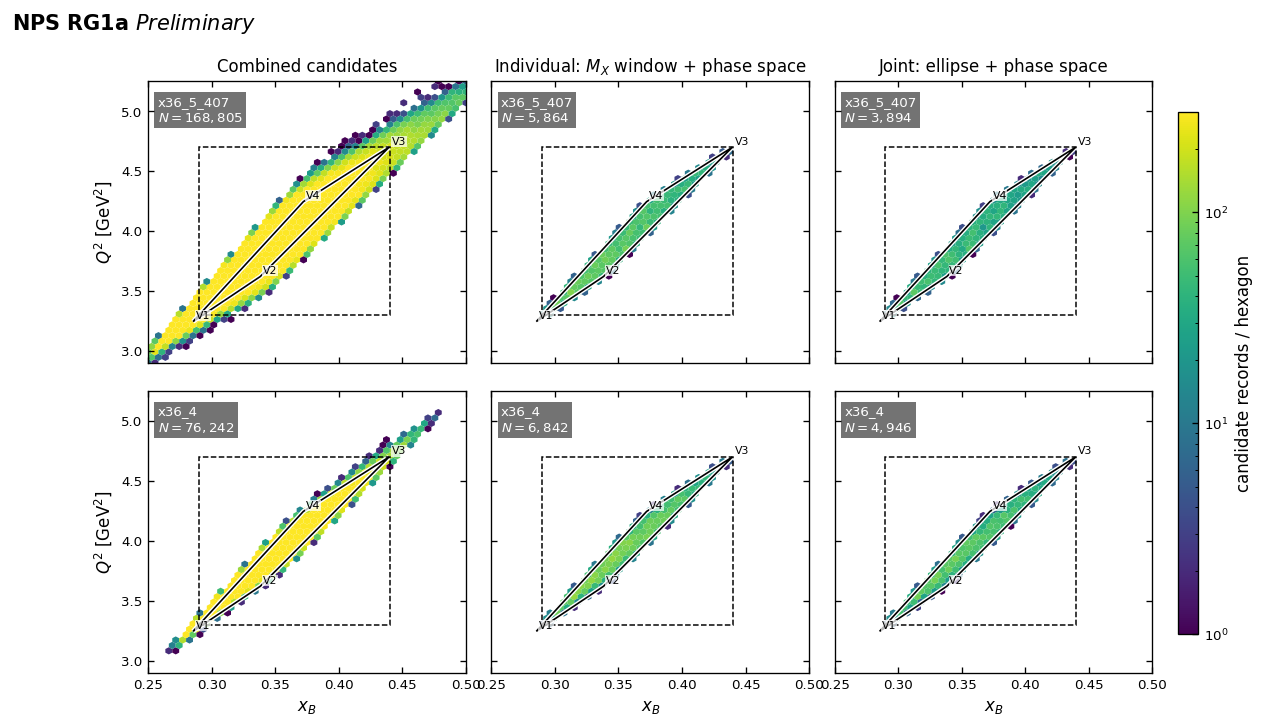

In [5]:
fig,axes=plt.subplots(2,3,figsize=(10.8,6.4),sharex=True,sharey=True)
specs=[("all","Combined candidates"),("individual_final",r"Individual: $M_X$ window + phase space"),
       ("joint_final","Joint: ellipse + phase space")]
for i,k in enumerate(KIN_ORDER):
    f=phase[k]
    for j,(name,title) in enumerate(specs):
        ax=axes[i,j]; take=np.ones(len(f),bool) if name=="all" else selection_masks[k][name]
        ax.hexbin(f.loc[take,"xB"],f.loc[take,"Q2"],gridsize=46,extent=(.25,.50,2.9,5.25),
                  mincnt=1,norm=LogNorm(vmin=1,vmax=300),cmap="viridis",linewidths=0)
        ax.add_patch(Polygon(diamond,closed=True,fill=False,edgecolor="white",lw=2.7,zorder=5))
        ax.add_patch(Polygon(diamond,closed=True,fill=False,edgecolor="black",lw=1,zorder=6))
        ax.add_patch(Rectangle((xb_edges[0],q2_edges[0]),np.diff(xb_edges)[0],np.diff(q2_edges)[0],
                               fill=False,edgecolor="black",lw=.9,ls="--",zorder=6))
        for n,(xb,q2) in enumerate(diamond):
            ax.text(xb+.002,q2+.025,f"V{n+1}",fontsize=6.5,
                    bbox={"fc":"white","ec":"none","alpha":.72,"pad":.4},zorder=7)
        ax.text(.03,.95,f"{KIN_SHORT[k]}\n$N={take.sum():,}$",transform=ax.transAxes,va="top",
                color="white",fontsize=8,bbox={"fc":"black","ec":"none","alpha":.55,"pad":2})
        if i==0: ax.set_title(title)
        ax.set_xlim(.25,.50); ax.set_ylim(2.9,5.25)
        if i==1: ax.set_xlabel(r"$x_B$")
        if j==0: ax.set_ylabel(r"$Q^2$ [GeV$^2$]")
fig.subplots_adjust(right=.90,wspace=.08,hspace=.10)
cax=fig.add_axes([.92,.16,.015,.68])
fig.colorbar(mpl.cm.ScalarMappable(norm=LogNorm(vmin=1,vmax=300),cmap="viridis"),cax=cax,
             label="candidate records / hexagon")
preliminary(axes[0,2])
export_figure(fig,"01_phase_space_selection","Data phase space before/after individual-window and joint-ellipse selections, with exact diamond")


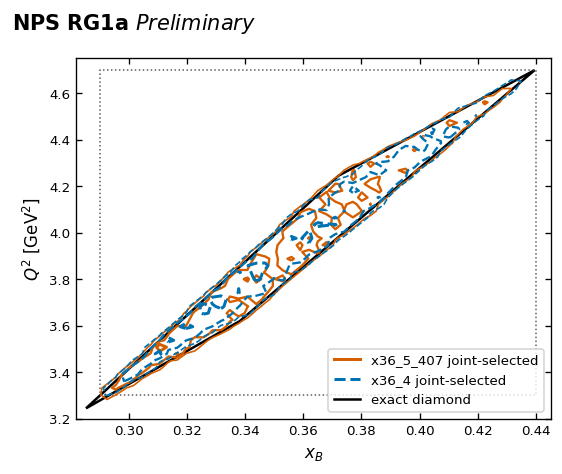

In [6]:
fig,ax=plt.subplots(figsize=(5.1,3.9))
xb_bins=np.linspace(.285,.445,54); q_bins=np.linspace(3.20,4.75,54)
for k,ls in zip(KIN_ORDER,["-","--"]):
    f=phase[k]; take=selection_masks[k]["joint_final"]
    h,xe,ye=np.histogram2d(f.loc[take,"xB"],f.loc[take,"Q2"],bins=(xb_bins,q_bins))
    h=h.T/max(h.max(),1)
    ax.contour((xe[:-1]+xe[1:])/2,(ye[:-1]+ye[1:])/2,h,levels=[.10,.35,.70],
               colors=[COLORS[k]],linestyles=ls,linewidths=[1,1.4,1.8])
ax.add_patch(Polygon(diamond,closed=True,fill=False,edgecolor="black",lw=1.5))
ax.add_patch(Rectangle((xb_edges[0],q2_edges[0]),np.diff(xb_edges)[0],np.diff(q2_edges)[0],
                       fill=False,edgecolor=".35",lw=.9,ls=":"))
ax.set(xlabel=r"$x_B$",ylabel=r"$Q^2$ [GeV$^2$]",xlim=(.282,.445),ylim=(3.20,4.75))
ax.legend(handles=[Line2D([0],[0],color=COLORS[KIN_ORDER[0]],lw=1.8,ls="-",label="x36_5_407 joint-selected"),
 Line2D([0],[0],color=COLORS[KIN_ORDER[1]],lw=1.8,ls="--",label="x36_4 joint-selected"),
 Line2D([0],[0],color="black",lw=1.5,label="exact diamond")],loc="lower right")
preliminary(ax)
export_figure(fig,"02_phase_space_overlap","Overlap of joint-selected x36_4 and x36_5_407 Q2-xB density contours")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


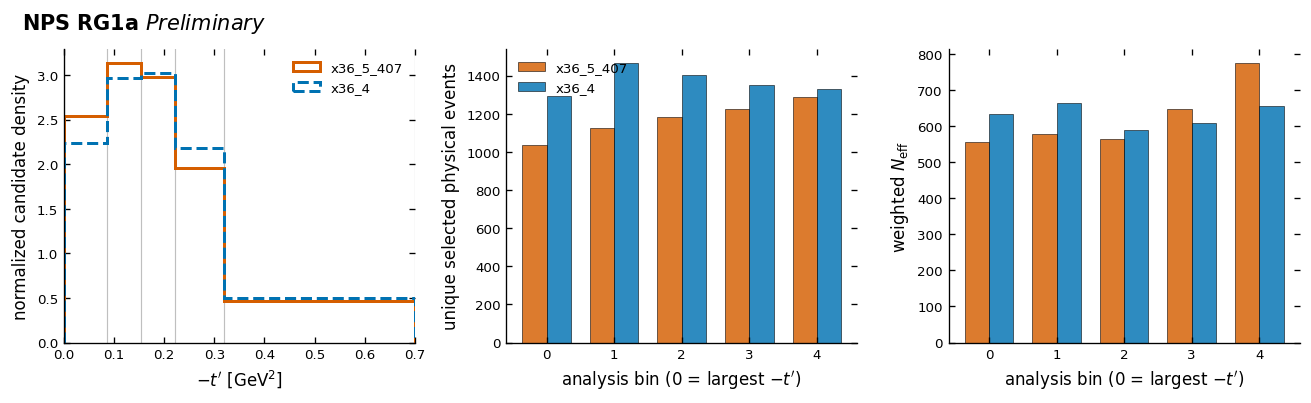

In [7]:
raw_counts={}
for k in KIN_ORDER:
    f=phase[k].loc[selection_masks[k]["individual_final"]].copy()
    f["tprime_bin"]=np.searchsorted(tprime_edges,f.tprime,side="right")-1
    counts=(f.drop_duplicates(["run_number","event_id","tprime_bin"]).groupby("tprime_bin").size()
              .reindex(range(5),fill_value=0))
    raw_counts[k]=counts.to_numpy()
fig,axes=plt.subplots(1,3,figsize=(11,3.35))
positive_edges=-tprime_edges[::-1]
for k,ls in zip(KIN_ORDER,["-","--"]):
    v=-phase[k].loc[selection_masks[k]["individual_final"],"tprime"].to_numpy()
    axes[0].hist(v,bins=positive_edges,density=True,histtype="step",lw=1.8,color=COLORS[k],ls=ls,label=KIN_SHORT[k])
for edge in positive_edges: axes[0].axvline(edge,color=".75",lw=.7,zorder=0)
axes[0].set(xlabel=r"$-t'$ [GeV$^2$]",ylabel="normalized candidate density",xlim=(0,.70)); axes[0].legend(frameon=False)
x=np.arange(5); width=.36
for off,k in zip([-width/2,width/2],KIN_ORDER):
    axes[1].bar(x+off,raw_counts[k],width,color=COLORS[k],alpha=.82,edgecolor="black",linewidth=.4,label=KIN_SHORT[k])
    axes[2].bar(x+off,bin_stats[k].sort_values("tprime_bin").effective_entries,width,color=COLORS[k],alpha=.82,edgecolor="black",linewidth=.4)
axes[1].set(xlabel="analysis bin (0 = largest $-t'$)",ylabel="unique selected physical events",xticks=x); axes[1].legend(frameon=False)
axes[2].set(xlabel="analysis bin (0 = largest $-t'$)",ylabel=r"weighted $N_{\rm eff}$",xticks=x)
for ax in axes: ax.spines[["top","right"]].set_visible(False)
preliminary(axes[2]); fig.tight_layout()
export_figure(fig,"03_tprime_binning_occupancy","Exact t-prime bins, unique selected-event occupancy, and weighted effective entries")


## Extracted U, LT, and TT responses

Open markers are individual fits; filled markers are the simultaneous joint fit. Horizontal
bars span physical bin boundaries; small horizontal offsets separate markers for display
only. Statistical bars follow the stored release rule: basic 16–84% intervals where flagged,
otherwise symmetric delta68 radii. Joint translucent boxes are the separate fully correlated
2.397% target-divisor scale systematic. No individual systematic was released, so none is
invented. Points are not connected.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


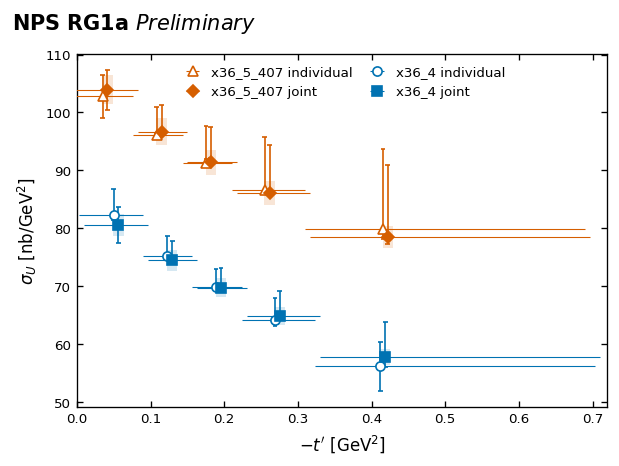

In [8]:
def interval_bounds(value,delta,lower,upper,use_basic):
    value=np.asarray(value,float); delta=np.asarray(delta,float); flag=np.asarray(use_basic,bool)
    low=np.where(flag,np.asarray(lower,float),value-delta)
    high=np.where(flag,np.asarray(upper,float),value+delta)
    if np.any(high<low) or not np.isfinite(np.vstack([low,high])).all(): raise ValueError("Bad interval")
    return low,high

def response_series(component):
    out=[]
    for k in KIN_ORDER:
        a=individual[k].sort_values("tprime_bin")
        d=individual_residual[k].query("component == @component").sort_values("tprime_bin")
        out.append({"kind":"Individual","kin":k,"x":-a.response_weighted_tprime.to_numpy(),
          "y":a[f"sigma_{component}"].to_numpy(),
          "bounds":interval_bounds(a[f"sigma_{component}"],a[f"{component}_delta68_stat"],
                                   d.basic_interval_lower,d.basic_interval_upper,d.use_basic_interval),
          "systematic":None})
        a=joint.query("kinematic == @k and component == @component").sort_values("truth_block")
        names=[f"{k}:{component}(bin{i})" for i in range(5)]
        d=joint_residual.set_index("quantity").loc[names]
        out.append({"kind":"Joint","kin":k,"x":-a.response_weighted_tprime.to_numpy(),"y":a.value.to_numpy(),
          "bounds":interval_bounds(a.value,a.delta68_stat,a.basic_interval_lower,a.basic_interval_upper,d.use_basic_interval),
          "systematic":a.target_systematic.to_numpy()})
    return out

def draw_interval(ax,x,low,high,color):
    ax.vlines(x,low,high,color=color,lw=1,zorder=2)
    cap=.0032
    ax.hlines(low,x-cap,x+cap,color=color,lw=1,zorder=2)
    ax.hlines(high,x-cap,x+cap,color=color,lw=1,zorder=2)

def plot_response(component,stem):
    fig,ax=plt.subplots(figsize=(5.2,3.9)); offsets=[-.010,-.0035,.0035,.010]
    joint_marker={"KinC_x36_5_407":"D","KinC_x36_4":"s"}
    for off,item in zip(offsets,response_series(component)):
        x=item["x"]; xd=x+off; lo=-tprime_edges[1:]; hi=-tprime_edges[:-1]
        xerr=np.vstack([x-lo,hi-x]); low,high=item["bounds"]
        marker=MARKERS[item["kin"]] if item["kind"]=="Individual" else joint_marker[item["kin"]]
        fill="white" if item["kind"]=="Individual" else COLORS[item["kin"]]
        if item["systematic"] is not None:
            for xp,yp,sy in zip(xd,item["y"],item["systematic"]):
                ax.add_patch(Rectangle((xp-.007,yp-sy),.014,2*sy,facecolor=COLORS[item["kin"]],edgecolor="none",alpha=.16,zorder=1))
        draw_interval(ax,xd,low,high,COLORS[item["kin"]])
        ax.errorbar(xd,item["y"],xerr=xerr,fmt=marker,ls="none",color=COLORS[item["kin"]],
          markerfacecolor=fill,markeredgecolor=COLORS[item["kin"]],markeredgewidth=1,capsize=0,elinewidth=.65,
          label=f"{KIN_SHORT[item['kin']]} {item['kind'].lower()}",zorder=3)
    if component!="U":
        ax.axhline(0,color=".55",lw=.8,zorder=0)
        ax.set_ylim(top=1)
    ax.set(xlabel=r"$-t'$ [GeV$^2$]",ylabel=rf"{COMPONENT_LABEL[component]} [nb/GeV$^2$]",xlim=(0,.72))
    ax.legend(ncol=2,frameon=False,loc="upper center",handletextpad=.4,columnspacing=.8); preliminary(ax); fig.tight_layout()
    export_figure(fig,stem,f"{component} response: individual x36_4/x36_5_407 and joint fit with released intervals")

plot_response("U","04_sigma_U_individual_joint")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


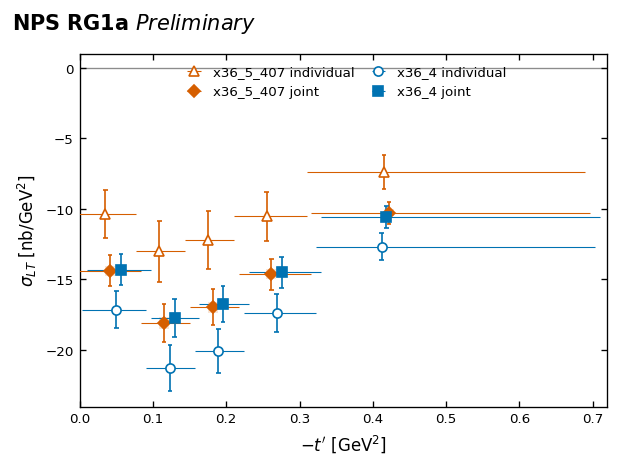

In [9]:
plot_response("LT","05_sigma_LT_individual_joint")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


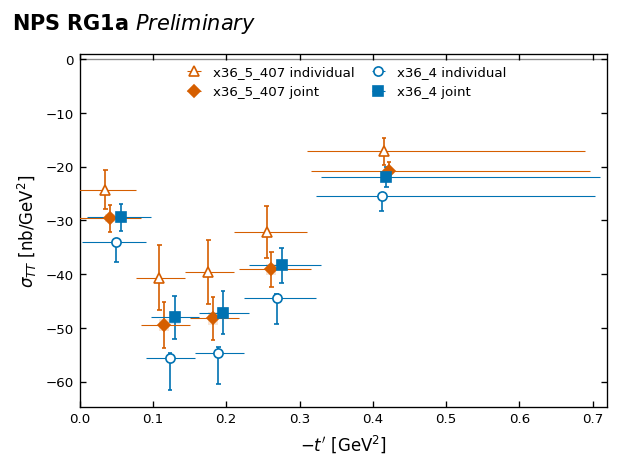

In [10]:
plot_response("TT","06_sigma_TT_individual_joint")


## Stored T/L separation

Nominal massless-electron central kinematics give $\epsilon=0.711500506617$ for
x36_5_407 and 0.516318176159 for x36_4. In each matched truth bin, the two joint
$\sigma_U$ values are transformed exactly through $\sigma_U=\sigma_T+\epsilon\sigma_L$;
the same transformation is applied to all 500 joint refit toys. Nominal-epsilon and
kinematic-centering/model uncertainties are not propagated. The target scale remains separate.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


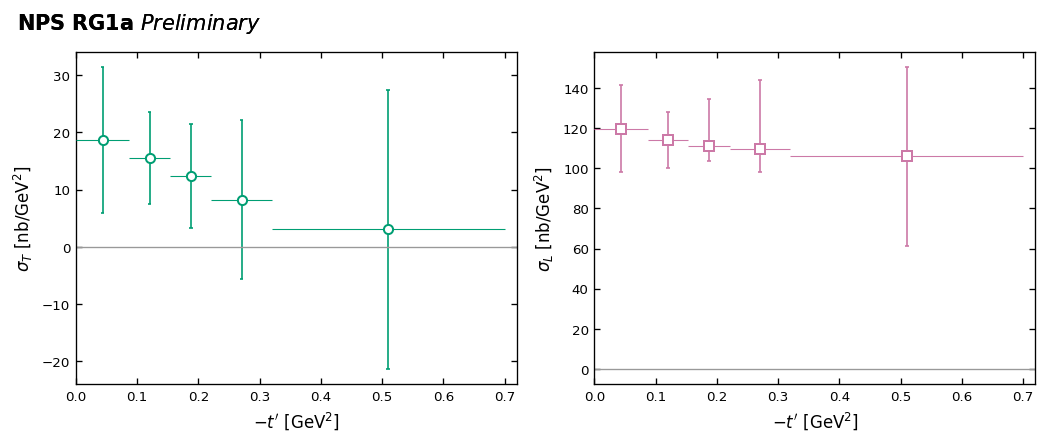

In [11]:
fig,axes=plt.subplots(1,2,figsize=(8.8,3.7),sharex=True)
for ax,c,color,marker in zip(axes,["T","L"],["#009E73","#CC79A7"],["o","s"]):
    a=lt.query("component == @c").sort_values("tprime_bin"); x=a.tprime_center.to_numpy(); y=a.central.to_numpy()
    low,high=interval_bounds(y,a.delta68_stat,a.basic_interval_lower,a.basic_interval_upper,a.use_basic_interval)
    lo=-tprime_edges[1:]; hi=-tprime_edges[:-1]; xerr=np.vstack([x-lo,hi-x])
    for xp,yp,sy in zip(x,y,a.target_scale_systematic):
        ax.add_patch(Rectangle((xp-.008,yp-sy),.016,2*sy,facecolor=color,edgecolor="none",alpha=.18,zorder=1))
    draw_interval(ax,x,low,high,color)
    ax.errorbar(x,y,xerr=xerr,fmt=marker,ls="none",color=color,markerfacecolor="white",
                markeredgewidth=1.2,capsize=0,elinewidth=.65,zorder=3)
    ax.axhline(0,color=".6",lw=.8); ax.set(xlabel=r"$-t'$ [GeV$^2$]",ylabel=rf"$\sigma_{c}$ [nb/GeV$^2$]",xlim=(0,.72))
    preliminary(ax)
fig.tight_layout()
export_figure(fig,"07_LT_separated_summary","Joint toy-calibrated transverse and longitudinal separated responses")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


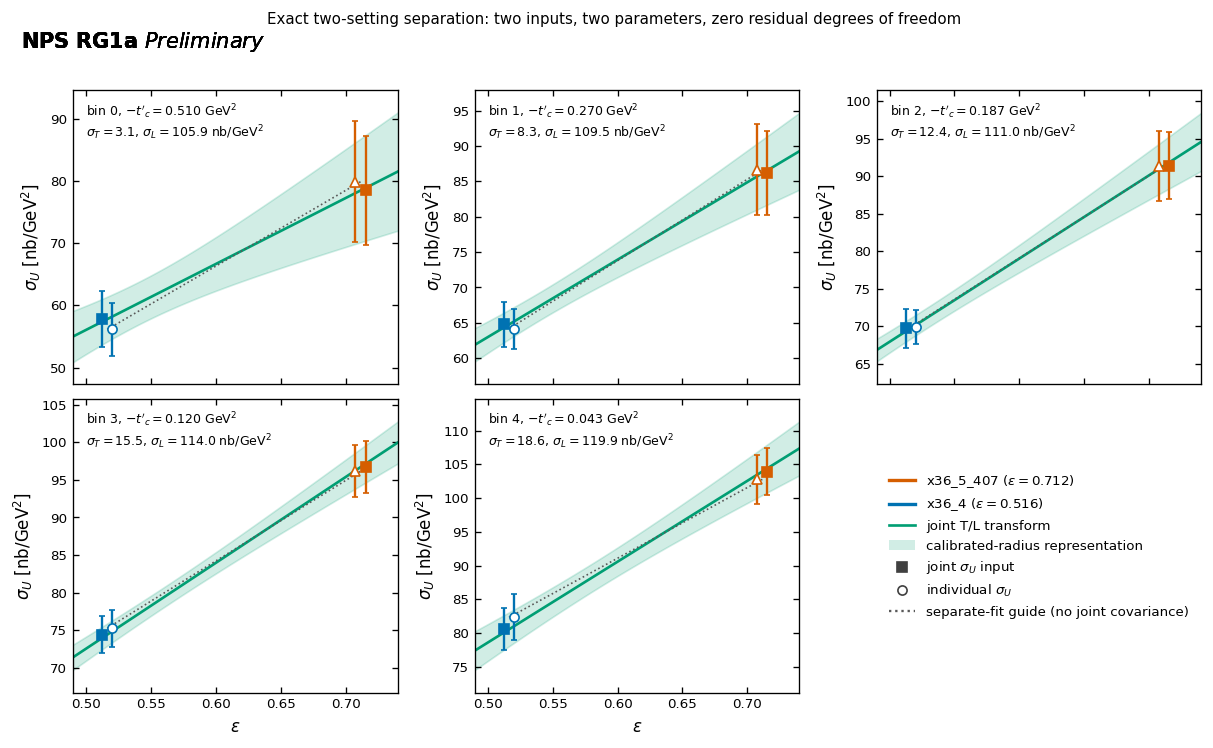

In [12]:
fig,axes=plt.subplots(2,3,figsize=(10.3,6.2),sharex=True); axes=axes.ravel()
eg=np.linspace(.48,.75,160)
for b in range(5):
    ax=axes[b]; tr=lt[(lt.component=="T")&(lt.tprime_bin==b)].iloc[0]; lr=lt[(lt.component=="L")&(lt.tprime_bin==b)].iloc[0]
    T,L=float(tr.central),float(lr.central); cov=lt_cov68[np.ix_([b,5+b],[b,5+b])]
    design=np.column_stack([np.ones_like(eg),eg]); band=np.sqrt(np.maximum(np.einsum("ij,jk,ik->i",design,cov,design),0))
    fit=T+eg*L; ax.fill_between(eg,fit-band,fit+band,color="#009E73",alpha=.18); ax.plot(eg,fit,color="#009E73",lw=1.6)
    ip=[]
    for k,shift in zip(KIN_ORDER,[.004,-.004]):
        e=epsilons[k]; j=joint[(joint.kinematic==k)&(joint.component=="U")&(joint.truth_block==b)].iloc[0]
        a=individual[k].query("tprime_bin == @b").iloc[0]
        ax.errorbar(e+shift,j.value,yerr=j.delta68_stat,fmt="s",color=COLORS[k],markerfacecolor=COLORS[k],capsize=2,zorder=4)
        ax.errorbar(e-shift,a.sigma_U,yerr=a.U_delta68_stat,fmt=MARKERS[k],color=COLORS[k],markerfacecolor="white",capsize=2,zorder=4)
        ip.append((e,a.sigma_U))
    ip.sort(); ax.plot([p[0] for p in ip],[p[1] for p in ip],color=".35",ls=":",lw=1)
    ax.text(.04,.96,rf"bin {b}, $-t'_c={tr.tprime_center:.3f}$ GeV$^2$"+f"\n"+rf"$\sigma_T={T:.1f}$, $\sigma_L={L:.1f}$ nb/GeV$^2$",
            transform=ax.transAxes,va="top",fontsize=7.5)
    ax.set_ylabel(r"$\sigma_U$ [nb/GeV$^2$]"); ax.set_xlim(.49,.74); preliminary(ax)
for ax in axes[3:5]: ax.set_xlabel(r"$\epsilon$")
axes[5].axis("off")
axes[5].legend(handles=[Line2D([0],[0],color=COLORS["KinC_x36_5_407"],lw=2,label="x36_5_407 ($\epsilon=0.712$)"),
 Line2D([0],[0],color=COLORS["KinC_x36_4"],lw=2,label="x36_4 ($\epsilon=0.516$)"),
 Line2D([0],[0],color="#009E73",lw=1.6,label="joint T/L transform"),
 Rectangle((0,0),1,1,facecolor="#009E73",alpha=.18,label="calibrated-radius representation"),
 Line2D([0],[0],marker="s",color=".25",ls="none",markerfacecolor=".25",label="joint $\sigma_U$ input"),
 Line2D([0],[0],marker="o",color=".25",ls="none",markerfacecolor="white",label="individual $\sigma_U$"),
 Line2D([0],[0],color=".35",ls=":",label="separate-fit guide (no joint covariance)")],
 loc="center",frameon=False,fontsize=8)
fig.text(.5,.995,"Exact two-setting separation: two inputs, two parameters, zero residual degrees of freedom",ha="center",va="top",fontsize=9)
fig.tight_layout(rect=(0,0,1,.97))
export_figure(fig,"08_rosenbluth_two_epsilon","Per-bin sigma_U versus epsilon with exact joint T/L lines, bands, and individual inputs")


## Fit quality and statistical diagnostics

Closure uses the frozen calibrated central campaign arrays, not an older generic report.
Pulls are $(y-\mu)/\sqrt{V_{\rm data}+V_{\rm MC}}$. The nominal chi-square probability is
descriptive only because positivity is active and the fit is boundary-constrained. The
accepted toys supply the published calibration; failed attempts are available only in aggregate.


### Numerical rank and conditioning

The first table keeps distinct diagnostic bases explicit. The **legacy no-SIMC** rows use the
canonical top-level products in `output/<setting>/xsec`. The **alternate-bin no-SIMC calibrated**
rows use `xsec_no_simc_model_calibrated` and the exact central fit recorded by each release's
`pipeline_linkage.json`. For both, rank and condition come from released whitened,
column-normalized migration singular values; $Q$ is reconstructed as
$\sum \mathrm{pull}_{\rm conditional}^2$ over included rows; nominal ndf is included rows minus
numerical design rank; and boundary counts come from the central positivity diagnostics.

The two no-SIMC versions have different published $t'$ edges. Legacy:
$[-0.75,-0.55,-0.40,-0.25,-0.13,0]$ GeV$^2$; alternate:
$[-0.70,-0.319544,-0.221239,-0.153472,-0.086719,0]$ GeV$^2$.

All Jacobian condition numbers use the 2-norm of a whitened, column-normalized Jacobian/design.
The M0-model values and ranks come from each frozen campaign's `feedin_refactor_validation.json`;
the joint value is recorded with the frozen central fit. The T/L value uses the repeated
two-$\epsilon$ design block (the inverse separation map has the same 2-norm condition number).

The second table reports direct SVD diagnostics of released calibrated covariance representations.
Those condition numbers describe covariance spectra and are not directly comparable to design
condition numbers.

In [13]:
# Alternate-bin no-SIMC calibrated releases and their explicitly linked central fits.
M0_JACOBIAN_PATH={
 "KinC_x36_5_407":REPO/"output/KinC_x36_5_407/xsec_simc_model/toy_campaigns/20261006T035631_3735066/feedin_refactor_validation.json",
 "KinC_x36_4":REPO/"output/KinC_x36_4/xsec_simc_model/toy_campaigns/20261006T040119_3879649/feedin_refactor_validation.json"}
m0_jacobian={k:load_json(path) for k,path in M0_JACOBIAN_PATH.items()}
for k,d in m0_jacobian.items():
    singular=np.asarray(d["scaled_jacobian_singular_values"],float)
    np.testing.assert_allclose(d["scaled_jacobian_condition"],singular[0]/singular[-1],rtol=1e-14)
    assert d["jacobian_rank"]==len(singular)==d["jacobian_columns"]

ALT_CAL_DIR={k:REPO/f"output/{k}/xsec_no_simc_model_calibrated" for k in KIN_ORDER}
alt_linkage={k:load_json(ALT_CAL_DIR[k]/"pipeline_linkage.json") for k in KIN_ORDER}
ALT_CENTRAL_DIR={k:Path(alt_linkage[k]["central_csv"]).parent for k in KIN_ORDER}
for k,d in ALT_CENTRAL_DIR.items():
    if d!=REPO/f"output/{k}/xsec_no_simc_model": raise ValueError(f"{k}: unexpected linked central directory {d}")
alt_summary={k:load_json(ALT_CAL_DIR[k]/"calibration_summary.json") for k in KIN_ORDER}
alt_bin={}; alt_residual={}; alt_cov={}; alt_cov_labels={}; alt_central={}
for k in KIN_ORDER:
    d=ALT_CAL_DIR[k]; c=ALT_CENTRAL_DIR[k]
    alt_bin[k]=load_csv(d/"bin_statistics.csv",
      ["truth_block","tprime_low","tprime_high","boundary_hit_rate"],["truth_block"])
    alt_residual[k]=load_csv(d/"toy_residual_statistics.csv",
      ["quantity","cross_validated_coverage","bias_over_delta68"],["quantity"])
    covdf=pd.read_csv(d/"published_covariance_calibrated68.csv")
    labels=covdf["quantity"].astype(str).tolist()
    if labels!=list(covdf.columns[2:]): raise ValueError(f"{k}: alternate covariance labels differ")
    alt_cov_labels[k]=labels; alt_cov[k]=covdf.iloc[:,2:].to_numpy(float)
    alt_central[k]={
      "singular":load_csv(c/"migration_singular_values.csv",
        ["index","whitened_column_normalized_singular_value"],["index"]),
      "parameters":load_csv(c/"migration_parameters.csv",
        ["parameter_index","region","component","is_nuisance"],["parameter_index"]),
      "rows":load_csv(c/"migration_reco_rows.csv",
        ["reco_row","pull_conditional","has_response","exclusion"],["reco_row"]),
      "positivity":load_csv(c/"positivity_diagnostics.csv",
        ["active_block_index","boundary_active","positivity_enabled"],["active_block_index"]),
      "status":load_csv(c/"fit_status.csv",
        ["iq","ix","fit_ok","fit_scope","failure_reason"],["iq","ix"])}

# Canonical legacy original-xsec fit/design diagnostics.
ORIGINAL_XSEC_DIR={k:REPO/f"output/{k}/xsec" for k in KIN_ORDER}
original_xsec={}
for k,d in ORIGINAL_XSEC_DIR.items():
    original_xsec[k]={
      "singular":load_csv(d/"migration_singular_values.csv",
        ["index","whitened_column_normalized_singular_value"],["index"]),
      "parameters":load_csv(d/"migration_parameters.csv",
        ["parameter_index","region","component","is_nuisance"],["parameter_index"]),
      "rows":load_csv(d/"migration_reco_rows.csv",
        ["reco_row","pull_conditional","has_response","exclusion"],["reco_row"]),
      "positivity":load_csv(d/"positivity_diagnostics.csv",
        ["active_block_index","boundary_active","positivity_enabled"],["active_block_index"]),
      "status":load_csv(d/"fit_status.csv",
        ["iq","ix","fit_ok","fit_scope","failure_reason"],["iq","ix"]),
      "slice":load_csv(d/"excl_xsec_pi0_analysis_no_simc_model_slice_summary.csv",
        ["it","tprime_lo","tprime_hi"],["it"])}

def original_design_diagnostic(k):
    o=original_xsec[k]
    singular=o["singular"].sort_values("index").whitened_column_normalized_singular_value.to_numpy(float)
    parameters=o["parameters"]; rows=o["rows"]; included=rows[rows.exclusion=="included"]
    assert len(included)>0 and np.isfinite(included.pull_conditional).all()
    assert len(singular)==len(parameters) and o["status"].fit_ok.eq(1).all()
    tolerance=max(len(included),len(parameters))*np.finfo(float).eps*singular.max()
    rank=int(np.sum(singular>tolerance)); boundary=int(o["positivity"].boundary_active.sum())
    published=int((parameters.is_nuisance==0).sum())
    return {"analysis":f"{KIN_SHORT[k]} no-SIMC legacy","diagnostic basis":"whitened normalized migration design",
      "rows / inputs":f"{len(included)} included / {len(rows)} total",
      "parameters / outputs":f"{len(parameters)} / {published}","rank":rank,
      "condition number":float(singular.max()/singular.min()),
      "objective Q":float(np.sum(included.pull_conditional.to_numpy(float)**2)),
      "nominal ndf":len(included)-rank,
      "boundary":f"fit OK; {boundary}/{len(o['positivity'])} active",
      "accepted toys":"not applicable","CV coverage68":"not applicable","max |bias|/delta68":np.nan}

def alternate_no_simc_diagnostic(k):
    o=alt_central[k]
    singular=o["singular"].sort_values("index").whitened_column_normalized_singular_value.to_numpy(float)
    parameters=o["parameters"]; rows=o["rows"]; included=rows[rows.exclusion=="included"]
    assert len(included)>0 and np.isfinite(included.pull_conditional).all()
    assert len(singular)==len(parameters) and o["status"].fit_ok.eq(1).all()
    tolerance=max(len(included),len(parameters))*np.finfo(float).eps*singular.max()
    rank=int(np.sum(singular>tolerance)); boundary=int(o["positivity"].boundary_active.sum())
    published=int((parameters.is_nuisance==0).sum()); residual=alt_residual[k]
    return {"analysis":f"{KIN_SHORT[k]} no-SIMC calibrated (alternate bins)",
      "diagnostic basis":"linked direct-bin no-SIMC design + calibration",
      "rows / inputs":f"{len(included)} included / {len(rows)} total",
      "parameters / outputs":f"{len(parameters)} / {published}","rank":rank,
      "condition number":float(singular.max()/singular.min()),
      "objective Q":float(np.sum(included.pull_conditional.to_numpy(float)**2)),
      "nominal ndf":len(included)-rank,
      "boundary":f"fit OK; {boundary}/{len(o['positivity'])} active",
      "accepted toys":alt_summary[k]["accepted"],
      "CV coverage68":f"{residual.cross_validated_coverage.min():.3f}–{residual.cross_validated_coverage.max():.3f}",
      "max |bias|/delta68":float(residual.bias_over_delta68.abs().max())}

# Fit/design diagnostics from original extraction, calibration summaries, and joint products.
epsilon_design=np.array([[1.0,epsilons[KIN_ORDER[0]]],[1.0,epsilons[KIN_ORDER[1]]]])
two_epsilon_rank=5*int(np.linalg.matrix_rank(epsilon_design))
two_epsilon_condition=float(np.linalg.cond(epsilon_design))

def coverage_range(values):
    a=np.asarray(values,float)
    return f"{a.min():.3f}–{a.max():.3f}"

fit_diagnostics=pd.DataFrame([
 original_design_diagnostic("KinC_x36_5_407"),
 original_design_diagnostic("KinC_x36_4"),
 alternate_no_simc_diagnostic("KinC_x36_5_407"),
 alternate_no_simc_diagnostic("KinC_x36_4"),
 {"analysis":"x36_5_407 M0-model calibrated","diagnostic basis":"frozen M0 whitened normalized Jacobian",
  "rows / inputs":m0_jacobian["KinC_x36_5_407"]["jacobian_rows"],
  "parameters / outputs":f"{m0_jacobian['KinC_x36_5_407']['total_parameters']} / 15",
  "rank":m0_jacobian["KinC_x36_5_407"]["jacobian_rank"],
  "condition number":m0_jacobian["KinC_x36_5_407"]["scaled_jacobian_condition"],
  "objective Q":individual_summary["KinC_x36_5_407"]["frozen_m0_q"],
  "nominal ndf":m0_jacobian["KinC_x36_5_407"]["jacobian_rows"]-m0_jacobian["KinC_x36_5_407"]["jacobian_rank"],
  "boundary":"not reported","accepted toys":individual_summary["KinC_x36_5_407"]["accepted_toys"],
  "CV coverage68":f"{individual_summary['KinC_x36_5_407']['minimum_cross_validated_coverage68']:.3f}–{individual_summary['KinC_x36_5_407']['maximum_cross_validated_coverage68']:.3f}",
  "max |bias|/delta68":individual_summary["KinC_x36_5_407"]["maximum_abs_bias_over_delta68"]},
 {"analysis":"x36_4 M0-model calibrated","diagnostic basis":"frozen M0 whitened normalized Jacobian",
  "rows / inputs":m0_jacobian["KinC_x36_4"]["jacobian_rows"],
  "parameters / outputs":f"{m0_jacobian['KinC_x36_4']['total_parameters']} / 15",
  "rank":m0_jacobian["KinC_x36_4"]["jacobian_rank"],
  "condition number":m0_jacobian["KinC_x36_4"]["scaled_jacobian_condition"],
  "objective Q":individual_summary["KinC_x36_4"]["frozen_m0_q"],
  "nominal ndf":m0_jacobian["KinC_x36_4"]["jacobian_rows"]-m0_jacobian["KinC_x36_4"]["jacobian_rank"],
  "boundary":"not reported","accepted toys":individual_summary["KinC_x36_4"]["accepted_toys"],
  "CV coverage68":f"{individual_summary['KinC_x36_4']['minimum_cross_validated_coverage68']:.3f}–{individual_summary['KinC_x36_4']['maximum_cross_validated_coverage68']:.3f}",
  "max |bias|/delta68":individual_summary["KinC_x36_4"]["maximum_abs_bias_over_delta68"]},
 {"analysis":"joint central fit","diagnostic basis":"frozen central fit",
  "rows / inputs":central_json["rows"],"parameters / outputs":f"{joint_summary['parameter_count']} / {joint_summary['published_quantity_count']}",
  "rank":central_json["rank"],"condition number":central_json["condition"],
  "objective Q":central_json["objective"],"nominal ndf":central_json["rows"]-central_json["rank"],
  "boundary":central_json["boundary"],"accepted toys":joint_summary["accepted_toys"],
  "CV coverage68":coverage_range(joint_residual.cross_validated_coverage68),
  "max |bias|/delta68":joint_summary["maximum_abs_bias_over_delta68"]},
 {"analysis":"T/L separation","diagnostic basis":"two-epsilon linear design",
  "rows / inputs":"10 (2 settings x 5 bins)","parameters / outputs":"10 / 10",
  "rank":two_epsilon_rank,"condition number":two_epsilon_condition,
  "objective Q":np.nan,"nominal ndf":0,"boundary":"not applicable","accepted toys":lt_summary["accepted_toys"],
  "CV coverage68":coverage_range(lt.cross_validated_coverage68),
  "max |bias|/delta68":lt_summary["maximum_abs_bias_over_delta68"]}
])
fit_display=fit_diagnostics.copy()
fit_display["objective Q"]=fit_display["objective Q"].map(lambda x:"—" if pd.isna(x) else f"{x:.3f}")
fit_display["condition number"]=fit_display["condition number"].map(lambda x:f"{x:.3f}" if isinstance(x,(float,np.floating)) else x)
fit_display["max |bias|/delta68"]=fit_display["max |bias|/delta68"].map(lambda x:"—" if pd.isna(x) else f"{x:.3f}")
display(fit_display)

# Released calibrated covariance spectra, using the standard SVD rank tolerance.
def covariance_diagnostic(name,matrix,metadata_rank=np.nan):
    a=np.asarray(matrix,float); singular=np.linalg.svd(a,compute_uv=False)
    tolerance=max(a.shape)*np.finfo(float).eps*singular[0]
    rank=int(np.sum(singular>tolerance))
    return {"release":name,"dimension":a.shape[0],"metadata rank":metadata_rank,
            "numerical rank":rank,"SVD tolerance":tolerance,
            "largest singular value":singular[0],"smallest retained singular value":singular[rank-1],
            "covariance condition number":singular[0]/singular[rank-1]}

covariance_diagnostics=pd.DataFrame([
 covariance_diagnostic("x36_5_407 M0-model calibrated",individual_cov["KinC_x36_5_407"],
                       individual_summary["KinC_x36_5_407"]["published_covariance_rank"]),
 covariance_diagnostic("x36_4 M0-model calibrated",individual_cov["KinC_x36_4"],
                       individual_summary["KinC_x36_4"]["published_covariance_rank"]),
 covariance_diagnostic("x36_5_407 no-SIMC calibrated (alternate bins)",alt_cov["KinC_x36_5_407"]),
 covariance_diagnostic("x36_4 no-SIMC calibrated (alternate bins)",alt_cov["KinC_x36_4"]),
 covariance_diagnostic("joint responses",joint_cov68),
 covariance_diagnostic("T/L separated",lt_cov68)
])
cov_display=covariance_diagnostics.copy()
for column in ["SVD tolerance","largest singular value","smallest retained singular value","covariance condition number"]:
    cov_display[column]=cov_display[column].map(lambda x:f"{x:.4e}")
cov_display["metadata rank"]=cov_display["metadata rank"].map(lambda x:"—" if pd.isna(x) else str(int(x)))
display(cov_display)

fit_diagnostics.to_csv(OUTPUT_DIR/"fit_design_diagnostics.csv",index=False)
covariance_diagnostics.to_csv(OUTPUT_DIR/"covariance_spectrum_diagnostics.csv",index=False)
print("Wrote:",OUTPUT_DIR/"fit_design_diagnostics.csv")
print("Wrote:",OUTPUT_DIR/"covariance_spectrum_diagnostics.csv")

,analysis,diagnostic basis,rows / inputs,parameters / outputs,rank,condition number,objective Q,nominal ndf,boundary,accepted toys,CV coverage68,max |bias|/delta68
0,x36_5_407 no-SIMC legacy,whitened normalized migration design,53 included / 60 total,27 / 15,27,241.124,35.813,26,fit OK; 5/9 active,not applicable,not applicable,—
1,x36_4 no-SIMC legacy,whitened normalized migration design,56 included / 60 total,27 / 15,27,36.652,32.800,29,fit OK; 6/9 active,not applicable,not applicable,—
2,x36_5_407 no-SIMC calibrated (alternate bins),linked direct-bin no-SIMC design + calibration,60 included / 60 total,18 / 15,18,35.233,40.945,42,fit OK; 3/6 active,500,0.672–0.684,0.725
3,x36_4 no-SIMC calibrated (alternate bins),linked direct-bin no-SIMC design + calibration,60 included / 60 total,18 / 15,18,35.164,50.899,42,fit OK; 3/6 active,500,0.674–0.734,0.393
4,x36_5_407 M0-model calibrated,frozen M0 whitened normalized Jacobian,60,7 / 15,7,13.106,67.570,53,not reported,500,0.672–0.682,0.754
5,x36_4 M0-model calibrated,frozen M0 whitened normalized Jacobian,60,7 / 15,7,7.355,77.978,53,not reported,500,0.672–0.686,0.695
6,joint central fit,frozen central fit,120,10 / 30,10,11.568,162.404,110,True,500,0.672–0.690,0.771
7,T/L separation,two-epsilon linear design,10 (2 settings x 5 bins),10 / 10,10,14.136,—,0,not applicable,500,0.674–0.684,0.478


,release,dimension,metadata rank,numerical rank,SVD tolerance,largest singular value,smallest retained singular value,covariance condition number
0,x36_5_407 M0-model calibrated,15,4,15,6.5793e-13,1.9754e+02,1.5025e-05,1.3147e+07
1,x36_4 M0-model calibrated,15,4,15,2.0819e-13,6.2506e+01,5.6150e-06,1.1132e+07
2,x36_5_407 no-SIMC calibrated (alternate bins),15,—,15,1.7147e-11,5.1483e+03,7.6940e+00,6.6913e+02
3,x36_4 no-SIMC calibrated (alternate bins),15,—,15,3.2425e-11,9.7353e+03,4.2678e+00,2.2811e+03
4,joint responses,30,—,30,9.7156e-13,1.4585e+02,2.8073e-06,5.1955e+07
5,T/L separated,10,—,10,8.5463e-12,3.8489e+03,3.4235e-04,1.1243e+07


Wrote: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/publication_figures/x36_4_x36_5_407_calibrated/fit_design_diagnostics.csv
Wrote: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/publication_figures/x36_4_x36_5_407_calibrated/covariance_spectrum_diagnostics.csv


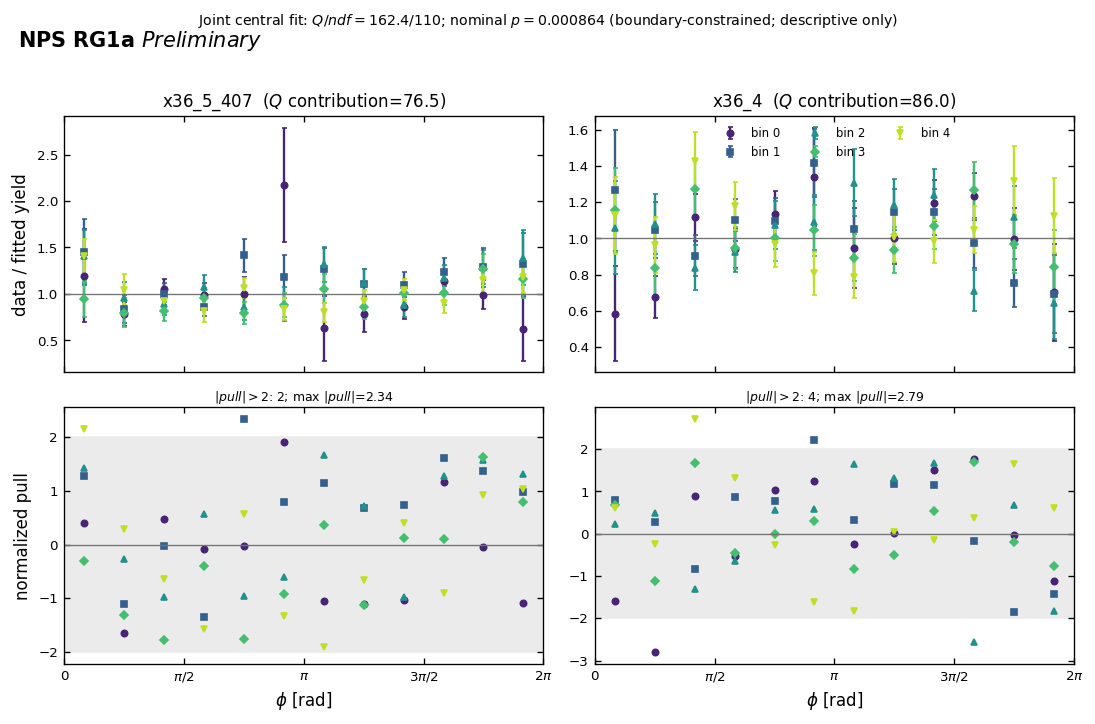

In [14]:
Q=float(np.sum(row_map.pull**2)); ndf=len(row_map)-int(central_json["rank"]); p_nominal=float(chi2_distribution.sf(Q,ndf))
np.testing.assert_allclose(Q,central_json["objective"],rtol=2e-12,atol=2e-12)
fig,axes=plt.subplots(2,2,figsize=(9.2,6),sharex="col")
bin_colors=mpl.colormaps["viridis"](np.linspace(.1,.9,5)); bin_markers=["o","s","^","D","v"]
for col,k in enumerate(KIN_ORDER):
    s=row_map[row_map.kinematic==k]
    for b,(color,marker) in enumerate(zip(bin_colors,bin_markers)):
        a=s[s.it==b]
        axes[0,col].errorbar(a.phi_center,a.ratio,yerr=a.ratio_error,fmt=marker,ls="none",ms=3.8,color=color,capsize=1.5,label=f"bin {b}")
        axes[1,col].plot(a.phi_center,a.pull,marker=marker,ls="none",ms=3.8,color=color)
    axes[0,col].axhline(1,color=".45",lw=.8); axes[1,col].axhline(0,color=".45",lw=.8); axes[1,col].axhspan(-2,2,color=".92",zorder=0)
    qs=float(np.sum(s.pull**2)); out=int(np.sum(np.abs(s.pull)>2))
    axes[0,col].set_title(f"{KIN_SHORT[k]}  ($Q$ contribution={qs:.1f})")
    axes[1,col].set_title(rf"$|pull|>2$: {out}; max $|pull|$={np.max(np.abs(s.pull)):.2f}",fontsize=7.5,pad=4)
    axes[1,col].set(xlabel=r"$\phi$ [rad]",xlim=(0,2*np.pi),xticks=[0,np.pi/2,np.pi,3*np.pi/2,2*np.pi],
      xticklabels=["0",r"$\pi/2$",r"$\pi$",r"$3\pi/2$",r"$2\pi$"])
axes[0,0].set_ylabel("data / fitted yield"); axes[1,0].set_ylabel("normalized pull")
axes[0,1].legend(ncol=3,frameon=False,fontsize=7,loc="upper center")
fig.suptitle(rf"Joint central fit: $Q/ndf={Q:.1f}/{ndf}$; nominal $p={p_nominal:.3g}$ (boundary-constrained; descriptive only)",
             fontsize=8.5,y=.995)
preliminary(axes[0,1]); fig.tight_layout(rect=(0,0,1,.955))
export_figure(fig,"09_joint_fit_closure_pulls","Frozen joint yield ratios and finite-MC normalized pulls versus phi")

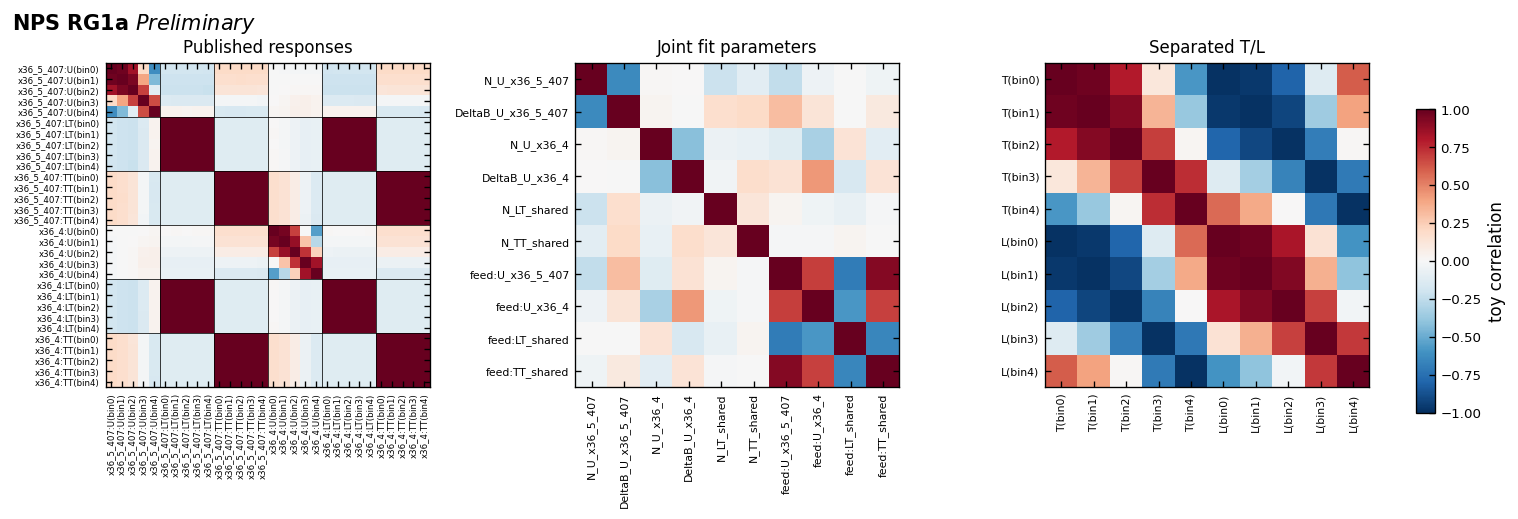

In [15]:
fig,axes=plt.subplots(1,3,figsize=(13,4.6))
items=[(published_corr,published_labels,"Published responses",[x.replace("KinC_","") for x in published_labels]),
       (parameter_corr,parameter_labels,"Joint fit parameters",[x.replace("KinC_","").replace("feedin_tprime_below_","feed:") for x in parameter_labels]),
       (lt_corr,lt_labels,"Separated T/L",lt_labels)]
for ax,(matrix,labels,title,short) in zip(axes,items):
    im=ax.imshow(matrix,vmin=-1,vmax=1,cmap="RdBu_r",interpolation="nearest"); ax.set_title(title)
    size=5.2 if len(labels)>15 else 6.5
    ax.set_xticks(range(len(labels)),short,rotation=90,fontsize=size); ax.set_yticks(range(len(labels)),short,fontsize=size)
    if len(labels)==30:
        for edge in [4.5,9.5,14.5,19.5,24.5]: ax.axhline(edge,color="black",lw=.45); ax.axvline(edge,color="black",lw=.45)
fig.subplots_adjust(left=.08,right=.89,bottom=.29,top=.89,wspace=.45)
cax=fig.add_axes([.92,.25,.012,.55])
fig.colorbar(im,cax=cax,label="toy correlation")
preliminary(axes[-1])
export_figure(fig,"10_correlation_matrices","Toy correlations for joint responses, fitted parameters, and separated T/L quantities")

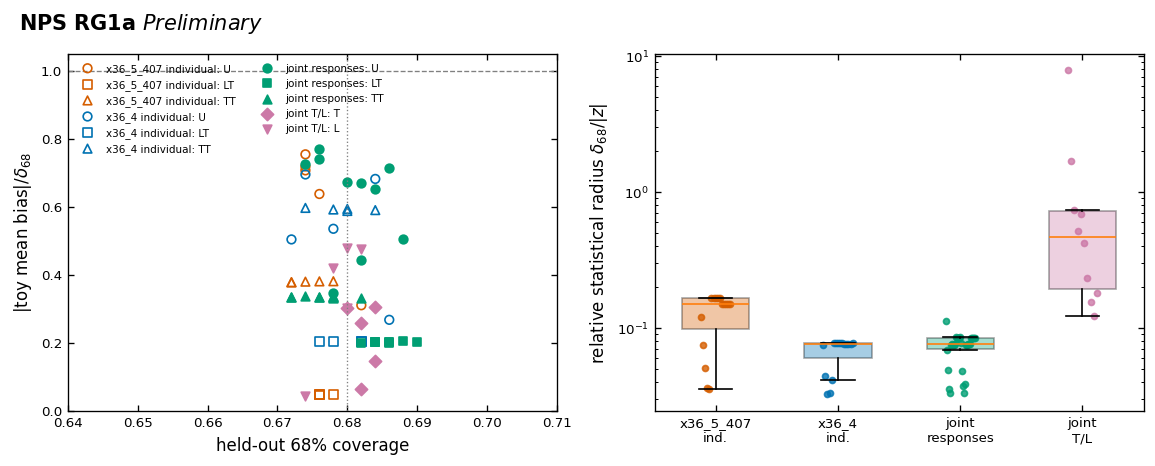

In [16]:
parts=[]
for k in KIN_ORDER:
    f=individual_residual[k].copy(); f["group"]=f"{KIN_SHORT[k]} individual"; f["relative_delta"]=f.delta68/np.maximum(f.central.abs(),1e-12)
    parts.append(f[["quantity","group","component","cross_validated_coverage68","abs_bias_over_delta68","relative_delta"]])
f=joint_residual.copy(); f["group"]="joint responses"; f["component"]=f.quantity.str.extract(r":(U|LT|TT)\(")
f["abs_bias_over_delta68"]=f.toy_mean_bias.abs()/f.delta68; f["relative_delta"]=f.delta68/np.maximum(f.central.abs(),1e-12)
parts.append(f[["quantity","group","component","cross_validated_coverage68","abs_bias_over_delta68","relative_delta"]])
f=lt.copy(); f["group"]="joint T/L"; f["abs_bias_over_delta68"]=f.toy_mean_bias.abs()/f.delta68_stat
f["relative_delta"]=f.delta68_stat/np.maximum(f.central.abs(),1e-12)
parts.append(f[["quantity","group","component","cross_validated_coverage68","abs_bias_over_delta68","relative_delta"]])
calibration=pd.concat(parts,ignore_index=True)
fig,axes=plt.subplots(1,2,figsize=(9.7,3.9))
gc={"x36_5_407 individual":COLORS["KinC_x36_5_407"],"x36_4 individual":COLORS["KinC_x36_4"],
    "joint responses":"#009E73","joint T/L":"#CC79A7"}; cm={"U":"o","LT":"s","TT":"^","T":"D","L":"v"}
for group,g in calibration.groupby("group",sort=False):
    for comp,a in g.groupby("component",sort=False):
        axes[0].scatter(a.cross_validated_coverage68,a.abs_bias_over_delta68,color=gc[group],marker=cm[comp],s=27,
          facecolors="none" if "individual" in group else gc[group],label=f"{group}: {comp}")
axes[0].axvline(.68,color=".5",lw=.8,ls=":"); axes[0].axhline(1,color=".5",lw=.8,ls="--")
axes[0].set(xlabel="held-out 68% coverage",ylabel=r"$|$toy mean bias$|/\delta_{68}$",xlim=(.64,.71),ylim=(0,1.05))
groups=list(gc); vals=[calibration.loc[calibration.group==g,"relative_delta"].to_numpy() for g in groups]
bp=axes[1].boxplot(vals,tick_labels=[g.replace(" individual","\nind.").replace("joint ","joint\n") for g in groups],
                   showfliers=False,patch_artist=True,widths=.55)
for patch,g in zip(bp["boxes"],groups): patch.set_facecolor(gc[g]); patch.set_alpha(.35)
for i,(g,v) in enumerate(zip(groups,vals),1): axes[1].scatter(i+np.linspace(-.12,.12,len(v)),v,s=13,color=gc[g],alpha=.8)
axes[1].set_yscale("log"); axes[1].set_ylabel(r"relative statistical radius $\delta_{68}/|z|$")
axes[0].legend(ncol=2,fontsize=6.2,frameon=False,loc="upper left"); preliminary(axes[1]); fig.tight_layout()
export_figure(fig,"11_toy_calibration_diagnostics","Held-out coverage versus toy bias and relative calibrated statistical precision")


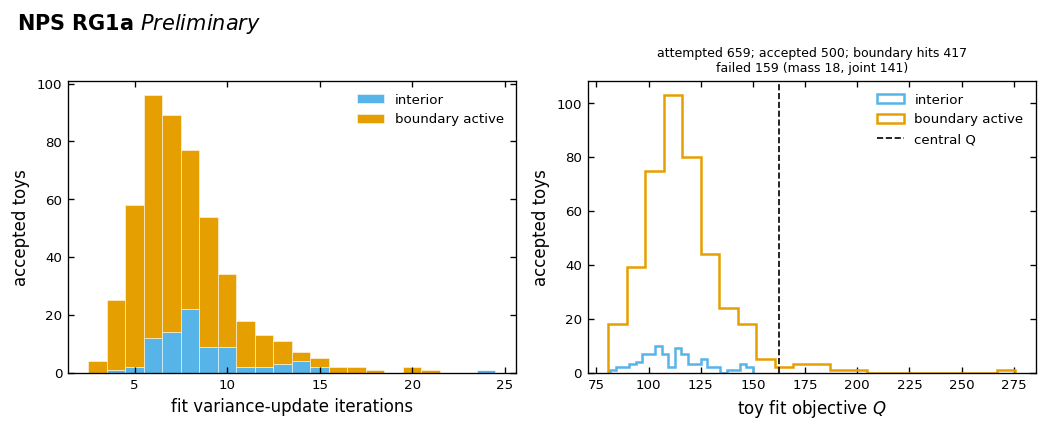

In [17]:
fig,axes=plt.subplots(1,2,figsize=(8.8,3.6)); boundary=toys["boundary_hit"]
bins=np.arange(toys["iterations"].min()-.5,toys["iterations"].max()+1.5)
axes[0].hist([toys["iterations"][~boundary],toys["iterations"][boundary]],bins=bins,stacked=True,
 color=["#56B4E9","#E69F00"],edgecolor="white",linewidth=.3,label=["interior","boundary active"])
axes[0].set(xlabel="fit variance-update iterations",ylabel="accepted toys"); axes[0].legend(frameon=False)
axes[1].hist(toys["q"][~boundary],bins=22,histtype="step",lw=1.5,color="#56B4E9",label="interior")
axes[1].hist(toys["q"][boundary],bins=22,histtype="step",lw=1.5,color="#E69F00",label="boundary active")
axes[1].axvline(central_json["objective"],color="black",lw=1,ls="--",label="central Q")
axes[1].set(xlabel="toy fit objective $Q$",ylabel="accepted toys"); axes[1].legend(frameon=False)
s=joint_summary["toy_summary"]
axes[1].set_title(f"attempted {s['attempted']}; accepted {s['accepted']}; boundary hits {s['boundary_hits']}\n"
                  f"failed {s['fit_failures']} (mass {s['mass_fit_failures']}, joint {s['joint_M0_failures']})",
                  fontsize=7.5,pad=6)
preliminary(axes[0])
fig.tight_layout(rect=(0,0,1,.94))
export_figure(fig,"12_joint_toy_convergence","Accepted joint-toy iteration/objective distributions with boundary and failure summary")

## Total angular cross section overlays

For each accepted $t'$ bin, the stored responses are combined with the nominal setting-specific
$\epsilon$ using the extraction convention

$$
\frac{d^2\sigma}{dt'\,d\phi}=\frac{1}{2\pi}\left[\sigma_U+
\sqrt{2\epsilon(1+\epsilon)}\,\sigma_{LT}\cos\phi+
\epsilon\,\sigma_{TT}\cos(2\phi)\right].
$$

The shaded intervals propagate the released calibrated response-covariance representation. The
joint-fit panel additionally shows the released fully correlated target-scale uncertainty as
thin dotted envelopes. Curves are response reconstructions, not refits to binned points.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


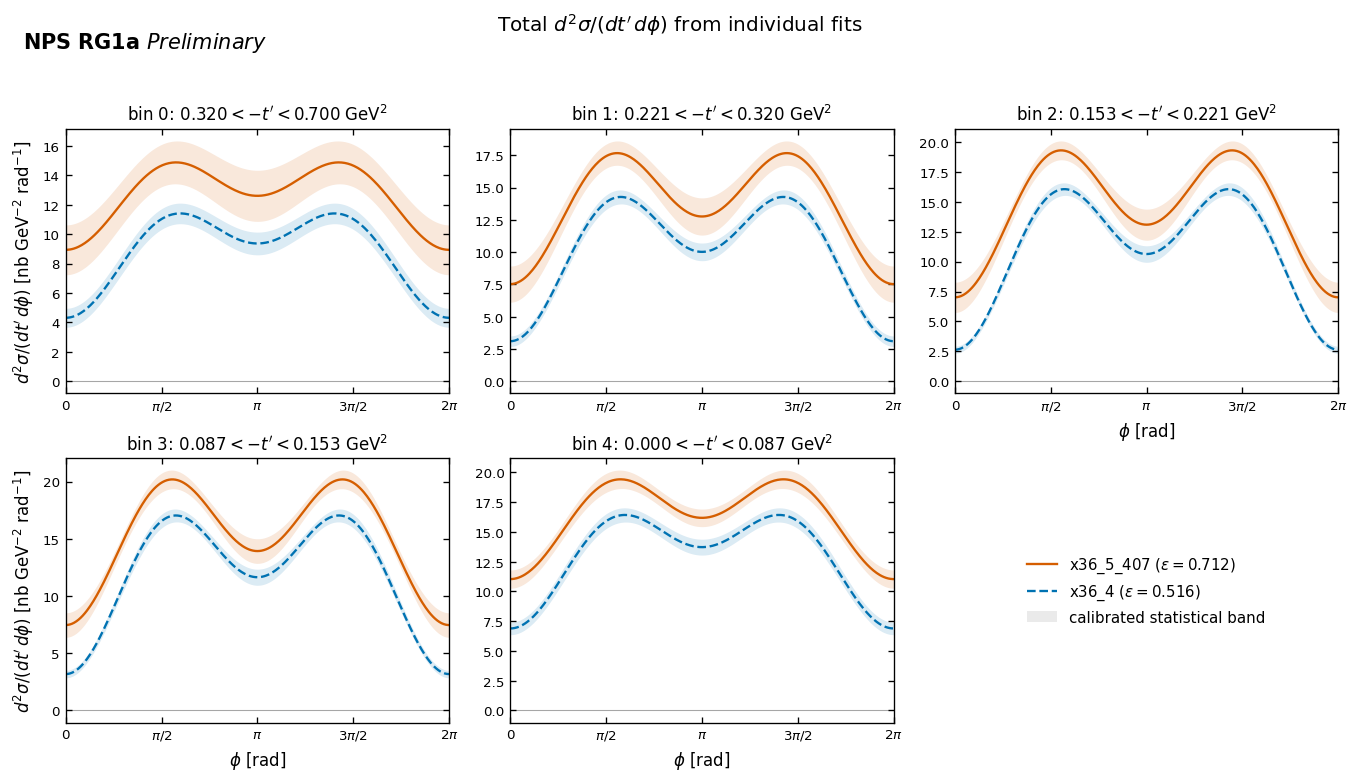

In [18]:
PHI_GRID=np.linspace(0,2*np.pi,361)
LINESTYLE={"KinC_x36_5_407":"-","KinC_x36_4":"--"}

def angular_basis(epsilon,phi=PHI_GRID):
    return np.vstack([np.ones_like(phi),
      np.sqrt(2*epsilon*(1+epsilon))*np.cos(phi),epsilon*np.cos(2*phi)])/(2*np.pi)

def angular_curve_band(coefficients,covariance,indices,epsilon):
    basis=angular_basis(epsilon)
    y=np.asarray(coefficients,float)@basis
    sub=np.asarray(covariance,float)[np.ix_(indices,indices)]
    delta=np.sqrt(np.maximum(0,np.einsum("in,ij,jn->n",basis,sub,basis)))
    return y,delta

def format_angular_axes(axes):
    for b,ax in enumerate(axes.flat[:5]):
        lo,hi=max(0.0,-tprime_edges[b+1]),max(0.0,-tprime_edges[b])
        ax.set_title(rf"bin {b}: ${lo:.3f} < -t' < {hi:.3f}$ GeV$^2$",pad=5)
        ax.set(xlim=(0,2*np.pi),xticks=[0,np.pi/2,np.pi,3*np.pi/2,2*np.pi],
               xticklabels=["0",r"$\pi/2$",r"$\pi$",r"$3\pi/2$",r"$2\pi$"])
        if b in [0,3]: ax.set_ylabel(r"$d^2\sigma/(dt'\,d\phi)$ [nb GeV$^{-2}$ rad$^{-1}$]")
        if b>=2: ax.set_xlabel(r"$\phi$ [rad]")
        ax.axhline(0,color=".65",lw=.65,zorder=0)
    axes.flat[5].axis("off")

fig,axes=plt.subplots(2,3,figsize=(11.4,6.5))
for b,ax in enumerate(axes.flat[:5]):
    for k in KIN_ORDER:
        a=individual[k].set_index("tprime_bin").loc[b]
        coeff=[a.sigma_U,a.sigma_LT,a.sigma_TT]
        y,dy=angular_curve_band(coeff,individual_cov[k],[b,5+b,10+b],epsilons[k])
        ax.fill_between(PHI_GRID,y-dy,y+dy,color=COLORS[k],alpha=.14,lw=0)
        ax.plot(PHI_GRID,y,color=COLORS[k],ls=LINESTYLE[k])
format_angular_axes(axes)
handles=[Line2D([0],[0],color=COLORS[k],ls=LINESTYLE[k],label=rf"{KIN_SHORT[k]} ($\epsilon={epsilons[k]:.3f}$)") for k in KIN_ORDER]
handles.append(Rectangle((0,0),1,1,fc=".55",alpha=.18,ec="none",label="calibrated statistical band"))
axes.flat[5].legend(handles=handles,loc="center",frameon=False,fontsize=9)
fig.suptitle(r"Total $d^2\sigma/(dt'\,d\phi)$ from individual fits",fontsize=12,y=.995)
preliminary(axes.flat[2]); fig.tight_layout(rect=(0,0,1,.95))
export_figure(fig,"13_total_angular_cross_section_individual","All-bin setting overlay of total angular cross sections from individual fits")

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


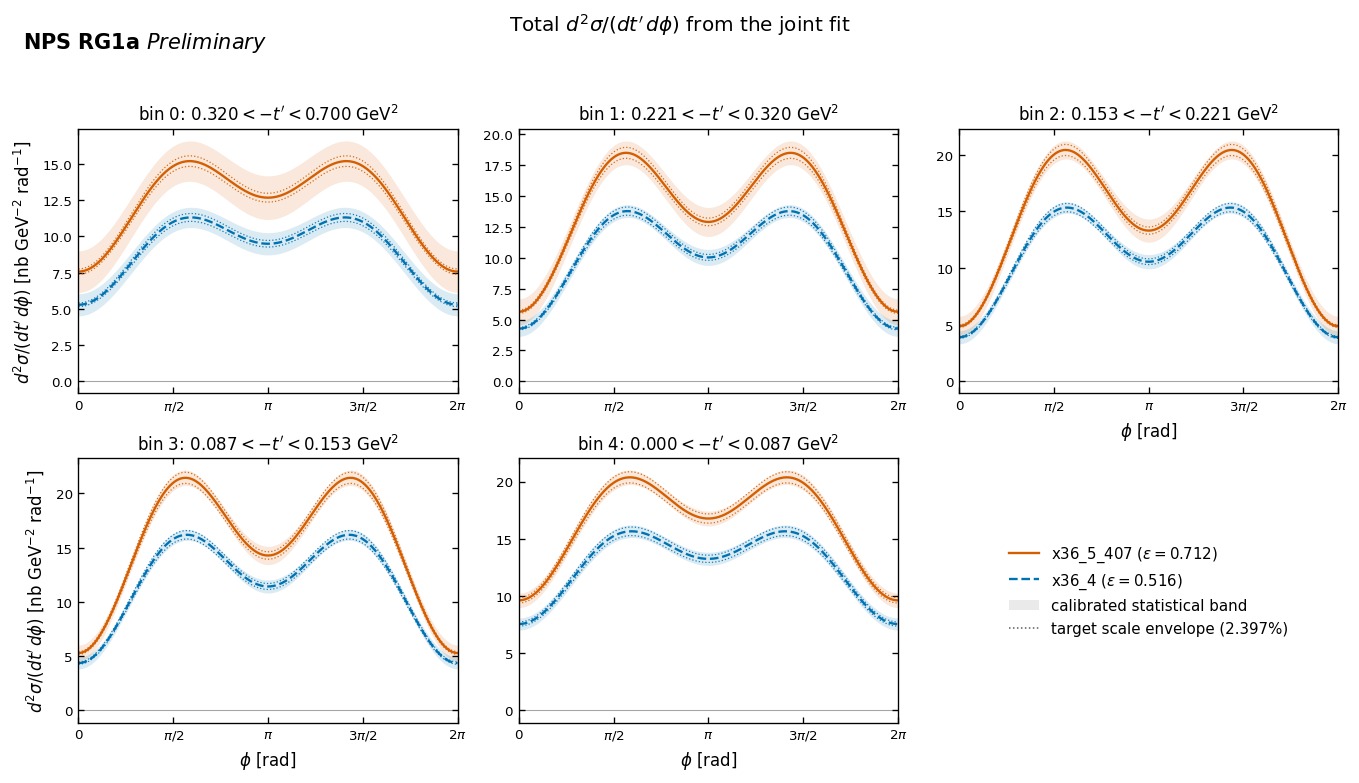

In [19]:
fig,axes=plt.subplots(2,3,figsize=(11.4,6.5))
joint_index={name:i for i,name in enumerate(joint_cov_labels)}
target_fraction=float((joint.target_systematic/joint.value.abs()).median())
for b,ax in enumerate(axes.flat[:5]):
    for k in KIN_ORDER:
        rows=joint[(joint.kinematic==k)&(joint.truth_block==b)].set_index("component")
        names=[f"{k}:{c}(bin{b})" for c in ["U","LT","TT"]]
        coeff=[rows.loc[c,"value"] for c in ["U","LT","TT"]]
        idx=[joint_index[n] for n in names]
        y,dy=angular_curve_band(coeff,joint_cov68,idx,epsilons[k])
        ax.fill_between(PHI_GRID,y-dy,y+dy,color=COLORS[k],alpha=.14,lw=0)
        ax.plot(PHI_GRID,y,color=COLORS[k],ls=LINESTYLE[k])
        ax.plot(PHI_GRID,y*(1+target_fraction),color=COLORS[k],ls=":",lw=.75,alpha=.9)
        ax.plot(PHI_GRID,y*(1-target_fraction),color=COLORS[k],ls=":",lw=.75,alpha=.9)
format_angular_axes(axes)
handles=[Line2D([0],[0],color=COLORS[k],ls=LINESTYLE[k],label=rf"{KIN_SHORT[k]} ($\epsilon={epsilons[k]:.3f}$)") for k in KIN_ORDER]
handles.extend([Rectangle((0,0),1,1,fc=".55",alpha=.18,ec="none",label="calibrated statistical band"),
                Line2D([0],[0],color=".35",ls=":",lw=.9,label=f"target scale envelope ({100*target_fraction:.3f}%)")])
axes.flat[5].legend(handles=handles,loc="center",frameon=False,fontsize=9)
fig.suptitle(r"Total $d^2\sigma/(dt'\,d\phi)$ from the joint fit",fontsize=12,y=.995)
preliminary(axes.flat[2]); fig.tight_layout(rect=(0,0,1,.95))
export_figure(fig,"14_total_angular_cross_section_joint","All-bin setting overlay of total angular cross sections from the joint fit")

## Presentation-ready combined diagnostics table

This compact table combines the original individual extractions, calibrated individual releases,
joint fit, and T/L separation. Design and covariance condition numbers remain in separate columns
because they diagnose different numerical objects.

,Analysis,tprime binning,Rows used,Parameters / outputs,Design rank,Jacobian condition (kappa2),Q / ndf,Boundary,Covariance rank (meta/SVD),Covariance condition (kappa2),Toy CV coverage68
0,x36_5_407 no-SIMC legacy,legacy 5-bin,53 / 60,27 / 15,27,241.12,35.813 / 26,5 / 9 active,—,—,—
1,x36_4 no-SIMC legacy,legacy 5-bin,56 / 60,27 / 15,27,36.65,32.800 / 29,6 / 9 active,—,—,—
2,x36_5_407 no-SIMC calibrated,alternate 5-bin,60 / 60,18 / 15,18,35.23,40.945 / 42,3 / 6 active,— / 15,6.69e+02,0.672–0.684
3,x36_4 no-SIMC calibrated,alternate 5-bin,60 / 60,18 / 15,18,35.16,50.899 / 42,3 / 6 active,— / 15,2.28e+03,0.674–0.734
4,x36_5_407 M0-model calibrated,alternate 5-bin,60,7 / 15,7,13.11,67.570 / 53,not reported,4 / 15,1.31e+07,0.672–0.682
5,x36_4 M0-model calibrated,alternate 5-bin,60,7 / 15,7,7.36,77.978 / 53,not reported,4 / 15,1.11e+07,0.672–0.686
6,joint central fit,alternate 5-bin,120,10 / 30,10,11.57,162.404 / 110,active,— / 30,5.20e+07,0.672–0.690
7,T/L separation,alternate 5-bin,10,10 / 10,10,14.14,— / 0,not applicable,— / 10,1.12e+07,0.674–0.684


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


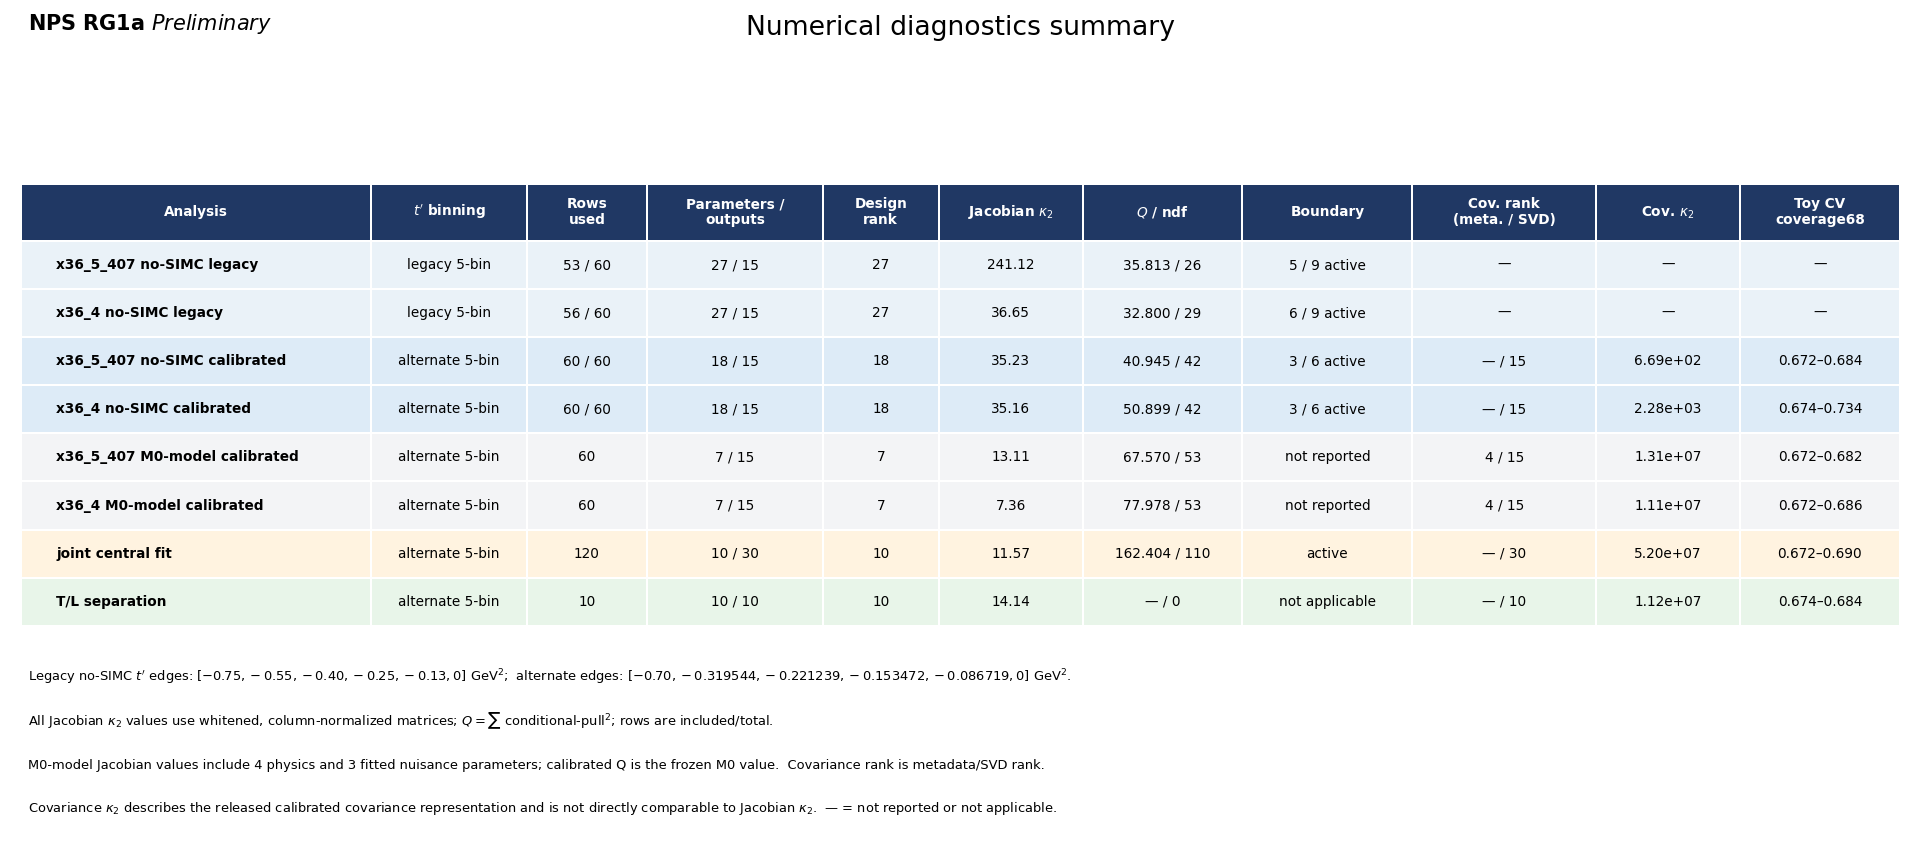

In [20]:
# Compact, presentation-oriented synthesis of the detailed tables above.
cov_by_name=covariance_diagnostics.set_index("release")

def cov_rank_text(name):
    r=cov_by_name.loc[name]
    metadata="—" if pd.isna(r["metadata rank"]) else str(int(r["metadata rank"]))
    return f"{metadata} / {int(r['numerical rank'])}"

def cov_condition_text(name):
    return f"{cov_by_name.loc[name,'covariance condition number']:.2e}"

combined_presentation_table=pd.DataFrame([
 {"Analysis":"x36_5_407 no-SIMC legacy","tprime binning":"legacy 5-bin","Rows used":"53 / 60","Parameters / outputs":"27 / 15",
  "Design rank":"27","Jacobian condition (kappa2)":"241.12","Q / ndf":"35.813 / 26","Boundary":"5 / 9 active",
  "Covariance rank (meta/SVD)":"—","Covariance condition (kappa2)":"—","Toy CV coverage68":"—"},
 {"Analysis":"x36_4 no-SIMC legacy","tprime binning":"legacy 5-bin","Rows used":"56 / 60","Parameters / outputs":"27 / 15",
  "Design rank":"27","Jacobian condition (kappa2)":"36.65","Q / ndf":"32.800 / 29","Boundary":"6 / 9 active",
  "Covariance rank (meta/SVD)":"—","Covariance condition (kappa2)":"—","Toy CV coverage68":"—"},
 {"Analysis":"x36_5_407 no-SIMC calibrated","tprime binning":"alternate 5-bin","Rows used":"60 / 60","Parameters / outputs":"18 / 15",
  "Design rank":"18","Jacobian condition (kappa2)":"35.23","Q / ndf":"40.945 / 42","Boundary":"3 / 6 active",
  "Covariance rank (meta/SVD)":cov_rank_text("x36_5_407 no-SIMC calibrated (alternate bins)"),
  "Covariance condition (kappa2)":cov_condition_text("x36_5_407 no-SIMC calibrated (alternate bins)"),"Toy CV coverage68":"0.672–0.684"},
 {"Analysis":"x36_4 no-SIMC calibrated","tprime binning":"alternate 5-bin","Rows used":"60 / 60","Parameters / outputs":"18 / 15",
  "Design rank":"18","Jacobian condition (kappa2)":"35.16","Q / ndf":"50.899 / 42","Boundary":"3 / 6 active",
  "Covariance rank (meta/SVD)":cov_rank_text("x36_4 no-SIMC calibrated (alternate bins)"),
  "Covariance condition (kappa2)":cov_condition_text("x36_4 no-SIMC calibrated (alternate bins)"),"Toy CV coverage68":"0.674–0.734"},
 {"Analysis":"x36_5_407 M0-model calibrated","tprime binning":"alternate 5-bin","Rows used":"60","Parameters / outputs":"7 / 15",
  "Design rank":"7","Jacobian condition (kappa2)":"13.11","Q / ndf":"67.570 / 53","Boundary":"not reported",
  "Covariance rank (meta/SVD)":cov_rank_text("x36_5_407 M0-model calibrated"),
  "Covariance condition (kappa2)":cov_condition_text("x36_5_407 M0-model calibrated"),"Toy CV coverage68":"0.672–0.682"},
 {"Analysis":"x36_4 M0-model calibrated","tprime binning":"alternate 5-bin","Rows used":"60","Parameters / outputs":"7 / 15",
  "Design rank":"7","Jacobian condition (kappa2)":"7.36","Q / ndf":"77.978 / 53","Boundary":"not reported",
  "Covariance rank (meta/SVD)":cov_rank_text("x36_4 M0-model calibrated"),
  "Covariance condition (kappa2)":cov_condition_text("x36_4 M0-model calibrated"),"Toy CV coverage68":"0.672–0.686"},
 {"Analysis":"joint central fit","tprime binning":"alternate 5-bin","Rows used":"120","Parameters / outputs":"10 / 30",
  "Design rank":"10","Jacobian condition (kappa2)":"11.57","Q / ndf":"162.404 / 110","Boundary":"active",
  "Covariance rank (meta/SVD)":cov_rank_text("joint responses"),"Covariance condition (kappa2)":cov_condition_text("joint responses"),
  "Toy CV coverage68":"0.672–0.690"},
 {"Analysis":"T/L separation","tprime binning":"alternate 5-bin","Rows used":"10","Parameters / outputs":"10 / 10",
  "Design rank":"10","Jacobian condition (kappa2)":"14.14","Q / ndf":"— / 0","Boundary":"not applicable",
  "Covariance rank (meta/SVD)":cov_rank_text("T/L separated"),"Covariance condition (kappa2)":cov_condition_text("T/L separated"),
  "Toy CV coverage68":"0.674–0.684"}
])
combined_presentation_table.to_csv(OUTPUT_DIR/"combined_numerical_diagnostics_presentation.csv",index=False)
jacobian_condition_table=combined_presentation_table[["Analysis","tprime binning","Design rank","Jacobian condition (kappa2)"]].copy()
jacobian_condition_table.columns=["Analysis","tprime binning","Jacobian rank","Jacobian condition (kappa2)"]
jacobian_condition_table.to_csv(OUTPUT_DIR/"jacobian_condition_numbers.csv",index=False)
display(combined_presentation_table)

column_labels=["Analysis",r"$t'$ binning","Rows\nused","Parameters /\noutputs","Design\nrank",r"Jacobian $\kappa_2$",
               r"$Q$ / ndf","Boundary","Cov. rank\n(meta. / SVD)",r"Cov. $\kappa_2$","Toy CV\ncoverage68"]
fig,ax=plt.subplots(figsize=(16.2,7.3)); ax.axis("off")
widths=[.175,.078,.06,.088,.058,.072,.08,.085,.092,.072,.08]
table=ax.table(cellText=combined_presentation_table.to_numpy(),colLabels=column_labels,
               cellLoc="center",colLoc="center",colWidths=widths,bbox=[.005,.285,.99,.58])
table.auto_set_font_size(False); table.set_fontsize(8.15)
row_colors=["#EAF2F8","#EAF2F8","#DDEBF7","#DDEBF7","#F3F4F6","#F3F4F6","#FFF3E0","#E8F5E9"]
for (row,col),cell in table.get_celld().items():
    cell.set_edgecolor("white"); cell.set_linewidth(1.2)
    if row==0:
        cell.set_facecolor("#203864"); cell.get_text().set_color("white"); cell.get_text().set_weight("bold")
        cell.set_height(.076)
    else:
        cell.set_facecolor(row_colors[row-1]); cell.set_height(.064)
        if col==0:
            cell.get_text().set_weight("bold"); cell.get_text().set_ha("left")
fig.suptitle("Numerical diagnostics summary",fontsize=16,y=.965)
fig.text(.02,.205,r"Legacy no-SIMC $t'$ edges: $[-0.75,-0.55,-0.40,-0.25,-0.13,0]$ GeV$^2$;  "
         r"alternate edges: $[-0.70,-0.319544,-0.221239,-0.153472,-0.086719,0]$ GeV$^2$.",fontsize=7.8,ha="left")
fig.text(.02,.155,r"All Jacobian $\kappa_2$ values use whitened, column-normalized matrices; "
         r"$Q=\sum$ conditional-pull$^2$; rows are included/total.",fontsize=7.8,ha="left")
fig.text(.02,.105,"M0-model Jacobian values include 4 physics and 3 fitted nuisance parameters; calibrated Q is the frozen M0 value.  "
         "Covariance rank is metadata/SVD rank.",fontsize=7.8,ha="left")
fig.text(.02,.055,r"Covariance $\kappa_2$ describes the released calibrated covariance representation and is not directly comparable to Jacobian $\kappa_2$.  "
         "— = not reported or not applicable.",fontsize=7.8,ha="left")
preliminary(ax); fig.subplots_adjust(left=.012,right=.988,bottom=.02,top=.89)
export_figure(fig,"15_combined_numerical_diagnostics_table","Presentation-ready combined table including legacy and alternate-bin no-SIMC, M0-model, joint, and T/L diagnostics")

## Export and immutability validation

Every canvas is exported once as vector PDF and once as a 320-dpi PNG. The checks below
verify the intended count, nonempty format signatures, readable PNG dimensions, and unchanged
input hashes after plotting.


In [21]:
from PIL import Image
figure_manifest=pd.DataFrame(FIGURE_RECORDS)
assert len(figure_manifest)==15 and figure_manifest.figure.is_unique
for r in FIGURE_RECORDS:
    pdf=REPO/r["PDF"]; png=REPO/r["PNG"]
    assert pdf.is_file() and pdf.stat().st_size>1000 and pdf.read_bytes()[:4]==b"%PDF"
    assert png.is_file() and png.stat().st_size>1000
    with Image.open(png) as im: im.verify()
    with Image.open(png) as im: assert im.width>=1200 and im.height>=900
changed=[rel for rel,(expected,_) in INPUTS.items() if sha256(REPO/rel)!=expected]
assert not changed,f"Read-only inputs changed: {changed}"
display(figure_manifest)
print(f"Validated {2*len(figure_manifest)} exports ({len(figure_manifest)} PDF + {len(figure_manifest)} PNG).")
print(f"Reverified {len(INPUTS)} input SHA-256 checksums after plotting: all unchanged.")

,figure,PDF,PNG,shows
0,01_phase_space_selection,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Data phase space before/after individual-windo...
1,02_phase_space_overlap,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Overlap of joint-selected x36_4 and x36_5_407 ...
2,03_tprime_binning_occupancy,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,"Exact t-prime bins, unique selected-event occu..."
3,04_sigma_U_individual_joint,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,U response: individual x36_4/x36_5_407 and joi...
4,05_sigma_LT_individual_joint,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,LT response: individual x36_4/x36_5_407 and jo...
5,06_sigma_TT_individual_joint,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,TT response: individual x36_4/x36_5_407 and jo...
6,07_LT_separated_summary,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Joint toy-calibrated transverse and longitudin...
7,08_rosenbluth_two_epsilon,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Per-bin sigma_U versus epsilon with exact join...
8,09_joint_fit_closure_pulls,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Frozen joint yield ratios and finite-MC normal...
9,10_correlation_matrices,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,"Toy correlations for joint responses, fitted p..."


Validated 30 exports (15 PDF + 15 PNG).
Reverified 64 input SHA-256 checksums after plotting: all unchanged.


## Scientific scope and limitations

- Phase-space figures begin with combined physics trees, not detector-raw events. They show
  extraction selections, the exact accepted diamond, overlap, and binning, but not upstream
  detector/PID cut flow.
- Individual releases contain calibrated statistical intervals but no released systematic
  uncertainty. Their angular-overlay bands use the stored calibrated covariance representation.
  Only joint and T/L products expose the separate fully correlated 2.397% target scale; it is
  shown separately and never combined silently with statistics.
- The two-$\epsilon$ T/L transformation has two inputs and two parameters per bin, hence no
  residual degrees of freedom. Its band uses the stored
  $\mathrm{diag}(\delta_{68})R_{\rm toy}\mathrm{diag}(\delta_{68})$ representation;
  $\delta_{68}^2$ is not asserted to be a Gaussian variance.
- Nominal-$\epsilon$ uncertainty and kinematic-centering/model uncertainty from different
  response-weighted $t'$ values are unavailable and not propagated.
- The joint central fit is boundary-active. Its nominal chi-square p-value is descriptive;
  coverage claims come from the accepted physical-event toy campaign.
- Per-start histories for the calibrated campaign and detailed records for 159 failed toy
  attempts are not stored. Available iterations, boundary flags, aggregate failures,
  correlations, coverage, residuals, and pulls are shown without fabricating diagnostics.